# llama.cpp, GGUF & Quantization — Running Real LLMs on One GPU

This notebook is about the *other* half of the deep-learning world: the one where a
model is a **single file on disk**, inference is a **C++ binary with no Python**, and
a 30-billion-parameter model runs on a consumer graphics card.

If you come from PyTorch, the mental model is:

| PyTorch / HuggingFace world | llama.cpp / GGUF world |
|---|---|
| `torch.nn.Module` graph built in Python | hard-coded C++ graph per architecture |
| weights in `.safetensors` / `.bin` shards + `config.json` + `tokenizer.json` | **one** `.gguf` file containing weights *and* config *and* tokenizer |
| `float32` / `bfloat16`, sometimes `int8` via bitsandbytes | ~30 block-quantized formats from 1.5 to 8.5 bits per weight |
| needs CUDA + Python + 4 GB of pip packages | one static binary, runs on CPU / CUDA / Metal / ROCm / Vulkan |
| optimized for **training** and batch throughput | optimized for **single-user inference** on limited memory |

### What you'll get out of this notebook

1. What GGUF actually *is*, byte for byte — with a **from-scratch parser** you run on a real 18 GB model file.
2. How a PyTorch (`.safetensors` / `.bin` / `.pt`) or TensorFlow model becomes a `.gguf`.
3. How a 30 B model gets loaded without 60 GB of RAM (`mmap`, sharding, lazy conversion).
4. What quantization *does* to a weight — implemented in NumPy, measured on real weights, and **decoded off disk from a real Q4_K tensor**.
5. Exactly how much VRAM a model needs, and **what actually fits on an RTX 3090 (24 GB)** — with measured numbers.
6. How to read a name like `qwen2.5-coder:32b` or `Qwen3-Coder-30B-A3B-Instruct-Q4_K_M.gguf`.
7. The coding-model landscape (Qwen, DeepSeek, …) and the `ollama` / `llama.cpp` / `aider` commands to drive them.

> **Everything measured in this notebook was run on a single RTX 3090 (24 GB, driver 580, CUDA 13)
> against `qwen3-coder:30b` (Qwen3-Coder-30B-A3B-Instruct, Q4_K_M).**
> The code cells auto-discover a GGUF file on your machine, so they work with whatever you have.

---

## 1. Where llama.cpp Sits

`llama.cpp` started as Georgi Gerganov's weekend project to run LLaMA on a MacBook. It is now the
de-facto standard for **local inference**, and the engine underneath **Ollama, LM Studio, Jan,
KoboldCpp, GPT4All, llamafile** and the `llama-cpp-python` bindings. When you type `ollama run`,
you are running llama.cpp.

It is built on **ggml** — a small C tensor library with its own graph, its own allocator, its own
quantized kernels, and no dependency on BLAS/PyTorch/Python.

```
        ┌──────────────────────────── ggml ────────────────────────────┐
        │  tensor type system (F32, F16, BF16, Q4_0 … Q6_K, IQ*, MXFP4)│
        │  graph builder + scheduler + allocator                       │
        │  backends: CPU(AVX2/AVX512/NEON) CUDA Metal ROCm Vulkan SYCL │
        └──────────────────────────────────────────────────────────────┘
                                   ▲
                                   │
        ┌────────────────────── llama.cpp ─────────────────────────────┐
        │  GGUF loader • per-architecture graph • KV cache • sampling  │
        │  tokenizer (BPE/SPM/WPM) • chat templates • grammars         │
        └──────────────────────────────────────────────────────────────┘
```

### The binaries you actually use

Note: these were renamed in mid-2024 — old tutorials say `./main` and `./server`.

| Binary | What it does |
|---|---|
| `llama-cli` | one-shot / interactive generation in the terminal |
| `llama-server` | HTTP server with an **OpenAI-compatible** `/v1/chat/completions` endpoint + web UI |
| `llama-quantize` | F16/BF16 GGUF → Q4_K_M / Q8_0 / IQ4_XS / … |
| `llama-imatrix` | computes an *importance matrix* over a calibration corpus (used by the good quants) |
| `llama-perplexity` | measures quality loss of a quant on wikitext |
| `llama-bench` | benchmarks prompt-processing (`pp`) and token-generation (`tg`) speed |
| `llama-gguf-split` | split / merge multi-part GGUF files |
| `convert_hf_to_gguf.py` | the **only** Python part: HuggingFace model dir → GGUF |

---

## 2. Model File Formats: `.pt` vs `.safetensors` vs `.gguf`

| | `.pt` / `.pth` / `.bin` | `.safetensors` | `.gguf` |
|---|---|---|---|
| **What it is** | Python **pickle** of a `state_dict` (ZIP container) | header (JSON) + raw tensor bytes | binary KV metadata + raw tensor bytes |
| **Security** | ⚠️ arbitrary code execution on load | safe — no code, pure data | safe — no code, pure data |
| **Self-describing?** | no (needs the Python class) | tensor names/shapes/dtypes only | **fully**: arch, hyper-params, tokenizer, chat template |
| **Quantized types** | no (fp32/bf16/fp16/int8) | no (fp32/bf16/fp16/fp8) | **yes** — that's the point |
| **Zero-copy `mmap`** | no | yes | yes |
| **Loads without Python** | no | yes (C++ lib exists) | yes |
| **Sharding** | manual, `*-00001-of-00005.bin` | manual + `model.safetensors.index.json` | `llama-gguf-split`, `*-00001-of-00003.gguf` |
| **Typical use** | legacy checkpoints, training resume | modern HF distribution | local inference |

A `.pt` file is a pickle: **`torch.load` on an untrusted `.pt` can execute code.** Since
PyTorch 2.6 the default is `weights_only=True`, which restricts the unpickler — but the reason
`safetensors` exists at all is that this was a real, exploited attack surface on the HF Hub.

GGUF's distinguishing feature is that it is **the whole model**. There is no `config.json` next to
it, no `tokenizer.json`, no `generation_config.json` — the vocabulary, the merges, the RoPE base,
the chat template, and the EOS token id all live inside the same file. That is why `ollama pull`
gives you one blob and it just runs.

> See also: [Model Saving & Loading (Serialization)](../serialization_saving_loading/index.ipynb)
> for the PyTorch-side story, and [PyTorch Tensor Basics & Data Types](../data_types/index.ipynb)
> for `dtype` fundamentals.

---

## 3. The GGUF File Format, Byte for Byte

GGUF ("GPT-Generated Unified Format") replaced the older GGML/GGMF/GGJT formats in August 2023.
It is little-endian, extensible, and has exactly three sections:

```
 offset 0
 ┌───────────────────────────────────────────────────────────────┐
 │ HEADER                                                        │
 │   char[4]  magic          = "GGUF"                            │
 │   uint32   version        = 3                                 │
 │   uint64   tensor_count                                       │
 │   uint64   metadata_kv_count                                  │
 ├───────────────────────────────────────────────────────────────┤
 │ METADATA  — metadata_kv_count × { key: string, type: u32,     │
 │                                    value: <typed> }           │
 │   general.architecture      = "qwen3moe"                      │
 │   qwen3moe.block_count      = 48                              │
 │   tokenizer.ggml.tokens     = [151936 strings]                │
 │   tokenizer.chat_template   = "{% macro render_item_list…"    │
 ├───────────────────────────────────────────────────────────────┤
 │ TENSOR INFO — tensor_count × { name: string,                  │
 │                                n_dims: u32, dims: u64[n_dims],│
 │                                ggml_type: u32, offset: u64 }  │
 │   note: offset is RELATIVE to the start of the data section   │
 ├───────────────────────────────────────────────────────────────┤
 │ ← padding to general.alignment (default 32)                   │
 ├───────────────────────────────────────────────────────────────┤
 │ TENSOR DATA — raw quantized blocks, back to back              │
 │              (this is the ~18 GB; it is mmap'd, never read    │
 │               into a buffer)                                  │
 └───────────────────────────────────────────────────────────────┘
```

Strings are `uint64 length` + UTF-8 bytes (**not** NUL-terminated). Arrays are
`uint32 element_type` + `uint64 count` + packed elements.

The metadata value types:

| id | type | id | type | id | type |
|---|---|---|---|---|---|
| 0 | `uint8` | 5 | `int32` | 10 | `uint64` |
| 1 | `int8` | 6 | `float32` | 11 | `int64` |
| 2 | `uint16` | 7 | `bool` | 12 | `float64` |
| 3 | `int16` | 8 | `string` | | |
| 4 | `uint32` | 9 | `array` | | |

That's the entire spec. Let's implement it.

In [1]:
"""A complete GGUF reader in ~70 lines of pure Python. No dependencies.

This parses the header + metadata + tensor index only — it never touches the
multi-GB data section, so it returns instantly on an 18 GB file.
"""
import struct
from collections import Counter

_FMT = {0: "<B", 1: "<b", 2: "<H", 3: "<h", 4: "<I", 5: "<i",
        6: "<f", 7: "<?", 10: "<Q", 11: "<q", 12: "<d"}

# ggml_type enum -> (name, elements per block, bytes per block)
GGML_TYPE = {
    0: ("F32",     1,   4), 1: ("F16",   1,   2), 30: ("BF16",   1,   2),
    2: ("Q4_0",   32,  18), 3: ("Q4_1", 32,  20),  6: ("Q5_0",  32,  22),
    7: ("Q5_1",   32,  24), 8: ("Q8_0", 32,  34),  9: ("Q8_1",  32,  36),
    10: ("Q2_K", 256,  84), 11: ("Q3_K", 256, 110), 12: ("Q4_K", 256, 144),
    13: ("Q5_K", 256, 176), 14: ("Q6_K", 256, 210), 15: ("Q8_K", 256, 292),
    16: ("IQ2_XXS", 256, 66), 17: ("IQ2_XS", 256, 74), 18: ("IQ3_XXS", 256, 98),
    19: ("IQ1_S", 256, 50), 20: ("IQ4_NL", 32, 18), 21: ("IQ3_S", 256, 110),
    22: ("IQ2_S", 256, 82), 23: ("IQ4_XS", 256, 136), 29: ("IQ1_M", 256, 56),
    39: ("MXFP4", 32, 17),
}


def read_gguf(path):
    f = open(path, "rb")

    def rd(fmt):
        return struct.unpack(fmt, f.read(struct.calcsize(fmt)))[0]

    def rd_str():
        return f.read(rd("<Q")).decode("utf-8", "replace")

    def rd_val(t):
        if t == 8:                                   # string
            return rd_str()
        if t == 9:                                   # array
            et, n = rd("<I"), rd("<Q")
            if et in (8, 9):
                return [rd_val(et) for _ in range(n)]
            sz = struct.calcsize(_FMT[et])
            return list(struct.unpack("<%d%s" % (n, _FMT[et][1]), f.read(n * sz)))
        return rd(_FMT[t])

    assert f.read(4) == b"GGUF", "not a GGUF file"
    version, n_tensors, n_kv = rd("<I"), rd("<Q"), rd("<Q")

    kv = {}
    for _ in range(n_kv):
        k = rd_str()
        kv[k] = rd_val(rd("<I"))

    tensors = []
    for _ in range(n_tensors):
        name = rd_str()
        dims = [rd("<Q") for _ in range(rd("<I"))]
        ttype, offset = rd("<I"), rd("<Q")
        tensors.append(dict(name=name, shape=dims,
                            type=GGML_TYPE[ttype][0], offset=offset))

    # tensor data starts after the index, padded up to general.alignment
    align = kv.get("general.alignment", 32)
    pos = f.tell()
    data_offset = pos + (-pos) % align
    f.close()
    return dict(version=version, kv=kv, tensors=tensors, data_offset=data_offset)


print("reader ready")

reader ready


### Find a GGUF file on this machine

Ollama stores its models as bare GGUF blobs under `~/.ollama/models/blobs/`, so if you have
pulled *anything* with Ollama you already have a GGUF file to inspect. (The manifest is JSON;
the big `sha256-…` blob is the GGUF.)

In [2]:
import glob, os

CANDIDATES = sorted(
    glob.glob(os.path.expanduser("~/.ollama/models/blobs/sha256-*"))
    + glob.glob(os.path.expanduser("~/**/*.gguf"), recursive=True)
    + glob.glob(os.path.expanduser("~/.cache/huggingface/hub/**/*.gguf"), recursive=True),
    key=lambda p: -os.path.getsize(p),
)

GGUF_PATH = None
for p in CANDIDATES:
    try:
        with open(p, "rb") as f:
            if f.read(4) == b"GGUF":
                GGUF_PATH = p
                break
    except OSError:
        pass

if GGUF_PATH is None:
    print("No GGUF found. Get one with:  ollama pull qwen2.5-coder:1.5b")
else:
    print(f"{GGUF_PATH}\n{os.path.getsize(GGUF_PATH) / 2**30:.2f} GiB")

/home/behnam/.ollama/models/blobs/sha256-1194192cf2a187eb02722edcc3f77b11d21f537048ce04b67ccf8ba78863006a
17.28 GiB


In [3]:
g = read_gguf(GGUF_PATH)
print(f"GGUF v{g['version']}   {len(g['tensors'])} tensors   "
      f"{len(g['kv'])} metadata keys   data starts at byte {g['data_offset']:,}\n")

for k, v in g["kv"].items():
    s = repr(v)
    print(f"  {k:<46} {s[:78]}{'…' if len(s) > 78 else ''}")

GGUF v3   579 tensors   35 metadata keys   data starts at byte 5,972,320

  general.architecture                           'qwen3moe'
  general.basename                               'Qwen3-Coder'
  general.file_type                              15
  general.finetune                               'Instruct'
  general.license                                'apache-2.0'
  general.license.link                           'https://huggingface.co/Qwen/Qwen3-Coder-30B-A3B-Instruct/blob/main/LICENSE'
  general.name                                   'Qwen3 Coder 30B A3B Instruct'
  general.parameter_count                        30532122624
  general.quantization_version                   2
  general.size_label                             '30B-A3B'
  general.tags                                   ['text-generation']
  general.type                                   'model'
  qwen3moe.attention.head_count                  32
  qwen3moe.attention.head_count_kv               4
  qwen3moe.attention.ke

Running that against `qwen3-coder:30b` on my machine prints (trimmed):

```
GGUF v3   579 tensors   35 metadata keys   data starts at byte 5,972,320

  general.architecture                           'qwen3moe'
  general.basename                               'Qwen3-Coder'
  general.finetune                               'Instruct'
  general.size_label                             '30B-A3B'
  general.file_type                              15                 ← 15 = Q4_K_M
  general.parameter_count                        30532122624
  general.quantization_version                   2
  qwen3moe.block_count                           48                 ← n_layers
  qwen3moe.embedding_length                      2048               ← d_model
  qwen3moe.attention.head_count                  32                 ← query heads
  qwen3moe.attention.head_count_kv               4                  ← GQA! 8:1 ratio
  qwen3moe.attention.key_length                  128                ← head_dim
  qwen3moe.attention.value_length                128
  qwen3moe.context_length                        262144             ← 256k trained ctx
  qwen3moe.expert_count                          128                ← MoE: 128 experts
  qwen3moe.expert_used_count                     8                  ← 8 active per token
  qwen3moe.expert_feed_forward_length            768
  qwen3moe.rope.freq_base                        10000000.0
  tokenizer.ggml.model                           'gpt2'             ← BPE
  tokenizer.ggml.tokens                          ['!', '"', '#', …] ← 151936 entries
  tokenizer.chat_template                        '{% macro render_item_list…'
```

**Read this like a `config.json`, because it is one.** Three things worth pointing out:

- `head_count=32` vs `head_count_kv=4` → **grouped-query attention**, 8 query heads share one
  KV head. This is what makes the KV cache 8× smaller than it would otherwise be, and it is the
  single biggest reason long contexts are affordable on a 24 GB card (§8).
- `expert_count=128`, `expert_used_count=8` → this is a **Mixture-of-Experts**. All 30.5 B
  parameters must sit in memory, but only ~3.3 B are multiplied per token. That's the "A3B"
  in the name (§10).
- `context_length=262144` is what the model was *trained* for. It is **not** what you should
  allocate — that's a VRAM decision you make at load time.

In [4]:
import numpy as np

BLK = {v[0]: (v[1], v[2]) for v in GGML_TYPE.values()}

rows, total_elems, total_bytes = [], 0, 0
for t in g["tensors"]:
    n = int(np.prod(t["shape"]))
    per_block, block_bytes = BLK[t["type"]]
    nbytes = n // per_block * block_bytes
    total_elems += n
    total_bytes += nbytes
    rows.append((t["type"], n, nbytes))

print(f"{'ggml type':<10}{'tensors':>9}{'params':>18}{'bytes':>18}{'bpw':>8}{'% of file':>11}")
for typ in sorted({r[0] for r in rows}):
    sel = [r for r in rows if r[0] == typ]
    e = sum(r[1] for r in sel); b = sum(r[2] for r in sel)
    print(f"{typ:<10}{len(sel):>9}{e:>18,}{b:>18,}{b * 8 / e:>8.2f}"
          f"{100 * b / total_bytes:>10.1f}%")

print(f"\ntotal params        {total_elems / 1e9:>8.2f} B")
print(f"total weight bytes  {total_bytes / 2**30:>8.2f} GiB")
print(f"effective bpw       {total_bytes * 8 / total_elems:>8.2f} bits/weight")
print(f"same model in bf16  {total_elems * 2 / 2**30:>8.2f} GiB")

ggml type   tensors            params             bytes     bpw  % of file
F32             241        12,793,856        51,175,424   32.00       0.3%
Q4_K            289    25,351,159,808    14,260,027,392    4.50      76.9%
Q6_K             49     5,168,168,960     4,239,513,600    6.56      22.9%

total params           30.53 B
total weight bytes     17.28 GiB
effective bpw           4.86 bits/weight
same model in bf16     56.87 GiB


On `qwen3-coder:30b` this prints:

```
ggml type   tensors            params             bytes     bpw  % of file
F32             241        12,793,856        51,175,424   32.00       0.3%
Q4_K            289    25,351,159,808    14,260,027,392    4.50      76.9%
Q6_K             49     5,168,168,960     4,239,513,600    6.56      22.9%

total params           30.53 B
total weight bytes     17.28 GiB
effective bpw           4.86 bits/weight
same model in bf16     56.87 GiB
```

**That is the entire value proposition in three numbers:** 56.87 GiB → 17.28 GiB, a 3.3× reduction,
which is the difference between "needs an A100" and "runs on the card in my desktop".

Notice it is not a single format. 289 tensors are Q4_K, 49 are Q6_K, and 241 (all the LayerNorm
scales and the MoE router) stayed **F32** — those 241 tensors are 0.04% of the parameters and
0.3% of the file, so keeping them at full precision is nearly free. That mix is what `_M` means
in `Q4_K_M`. We'll dissect it in §7.7.

---

## 4. PyTorch → GGUF

### The pipeline

```
  HuggingFace model directory
  ├── config.json               ← architecture + hyper-parameters
  ├── model-00001-of-00016.safetensors   ┐
  ├── …                                  ├─ ~61 GB of bf16 weights
  ├── model-00016-of-00016.safetensors   ┘
  ├── model.safetensors.index.json       ← which tensor lives in which shard
  ├── tokenizer.json / tokenizer.model
  └── generation_config.json
              │
              │  python convert_hf_to_gguf.py . --outtype bf16 --outfile m-bf16.gguf
              │      · maps HF tensor names   → ggml names
              │      · maps config.json keys  → gguf metadata keys
              │      · embeds the tokenizer + chat template
              │      · permutes Q/K weights for ggml's RoPE convention
              ▼
      m-bf16.gguf   (61 GB, lossless)
              │
              │  llama-imatrix -m m-bf16.gguf -f calibration.txt -o m.imatrix
              │  llama-quantize --imatrix m.imatrix m-bf16.gguf m-Q4_K_M.gguf Q4_K_M
              ▼
      m-Q4_K_M.gguf  (18 GB, runs on a 3090)
```

### The actual commands

```bash
# 0. get llama.cpp (build with CUDA — see §12)
git clone https://github.com/ggml-org/llama.cpp && cd llama.cpp
pip install -r requirements/requirements-convert_hf_to_gguf.txt

# 1. download the *unquantized* HF model (this is the big download)
pip install -U "huggingface_hub[cli]"
hf download Qwen/Qwen2.5-Coder-7B-Instruct --local-dir ./Qwen2.5-Coder-7B-Instruct

# 2. HF -> GGUF, no precision loss yet
python convert_hf_to_gguf.py ./Qwen2.5-Coder-7B-Instruct \
       --outtype bf16 \
       --outfile qwen2.5-coder-7b-bf16.gguf

# 3. (recommended) importance matrix over a calibration corpus
./build/bin/llama-imatrix -m qwen2.5-coder-7b-bf16.gguf \
       -f calibration_data.txt -o qwen7b.imatrix -ngl 99

# 4. quantize
./build/bin/llama-quantize --imatrix qwen7b.imatrix \
       qwen2.5-coder-7b-bf16.gguf qwen2.5-coder-7b-Q4_K_M.gguf Q4_K_M

# 5. run it
./build/bin/llama-server -m qwen2.5-coder-7b-Q4_K_M.gguf -ngl 99 -c 16384 --port 8080
```

`--outtype` accepts `f32`, `f16`, `bf16`, `q8_0` and `auto` (keeps the source dtype).
Use `bf16` or `f32` as the intermediate: quantizing **from** an already-quantized `q8_0`
file compounds the error.

### What `convert_hf_to_gguf.py` is actually doing

It is not a generic converter — it is a **registry of per-architecture converter classes**:

```python
@ModelBase.register("Qwen2ForCausalLM")
class Qwen2Model(TextModel):
    model_arch = gguf.MODEL_ARCH.QWEN2
    def set_gguf_parameters(self): ...     # config.json -> gguf KV
    def modify_tensors(self, data, name, bid): ...   # rename / reshape / permute
```

Four jobs:

1. **Tensor name mapping.** HF calls it `model.layers.0.self_attn.q_proj.weight`; ggml calls it
   `blk.0.attn_q.weight`. The mapping lives in `gguf-py/gguf/tensor_mapping.py`.
2. **Hyper-parameter mapping.** `config.json:num_hidden_layers` → `qwen3moe.block_count`, and so on.
3. **Layout fixes.** LLaMA-family Q/K projections get *permuted* because ggml implements RoPE with a
   different head layout than HF. Get this wrong and the model emits fluent garbage — a classic
   symptom of a hand-rolled conversion.
4. **Tokenizer embedding.** The full vocab, merges, token types, special-token ids and the Jinja
   chat template are copied into the metadata.

**If your architecture isn't in the registry, conversion fails** with
`Model <XForCausalLM> is not supported`. Your options: wait for upstream support, write a converter
class (~100 lines if it's close to an existing arch), or re-map your weights onto a supported
architecture. There is no automatic fallback, because llama.cpp needs a **hand-written C++ graph**
for every architecture anyway.

### `.pt` / `.bin` / `.pth` checkpoints

`convert_hf_to_gguf.py` reads both `.safetensors` and `.bin` shards, so a legacy HF repo works
directly. A bare `torch.save(model.state_dict(), "model.pt")` does **not** — there is no
`config.json`, so nothing knows the architecture. Convert it to an HF directory first:

```python
import torch
from transformers import AutoConfig, AutoModelForCausalLM

cfg = AutoConfig.from_pretrained("Qwen/Qwen2.5-Coder-7B-Instruct")
model = AutoModelForCausalLM.from_config(cfg, torch_dtype=torch.bfloat16)
model.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=True))

model.save_pretrained("./my-hf-model", safe_serialization=True)   # -> .safetensors shards
AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Coder-7B-Instruct").save_pretrained("./my-hf-model")
# now: python convert_hf_to_gguf.py ./my-hf-model --outtype bf16 --outfile out.gguf
```

**LoRA adapters** have their own path: `convert_lora_to_gguf.py` produces a GGUF adapter you pass
with `--lora`, or you merge it into the base with PEFT's `merge_and_unload()` before converting.

---

## 5. TensorFlow → GGUF

**There is no direct path, and you almost never want one.** Every architecture in
`convert_hf_to_gguf.py` reads PyTorch-layout tensors. The route is always TF → PyTorch → GGUF.

For a model that exists in both frameworks on the HF Hub:

```python
from transformers import AutoModelForCausalLM, AutoTokenizer

# from_tf=True reads TF checkpoint weights into the PyTorch class
model = AutoModelForCausalLM.from_pretrained("path/to/tf_model", from_tf=True)
model.save_pretrained("./hf_pt", safe_serialization=True)
AutoTokenizer.from_pretrained("path/to/tf_model").save_pretrained("./hf_pt")
# then: python convert_hf_to_gguf.py ./hf_pt --outtype bf16 --outfile out.gguf
```

For a raw Keras/SavedModel that isn't a `transformers` architecture, you're writing the bridge
yourself, and the traps are all layout:

| Trap | TF/Keras | PyTorch |
|---|---|---|
| Dense kernel | `[in, out]` | `[out, in]` — **transpose** |
| Conv2D kernel | `[kh, kw, in, out]` | `[out, in, kh, kw]` — `permute(3,2,0,1)` |
| LayerNorm | `gamma` / `beta` | `weight` / `bias` |
| Data layout | NHWC | NCHW |
| Embedding | `[vocab, dim]` | `[vocab, dim]` — same |

```python
import numpy as np, tensorflow as tf, torch

tfm = tf.keras.models.load_model("model.keras")
sd = {}
for w in tfm.weights:
    a = w.numpy()
    if a.ndim == 2:                  # Dense kernel
        a = a.T
    elif a.ndim == 4:                # Conv kernel
        a = a.transpose(3, 2, 0, 1)
    sd[remap(w.name)] = torch.from_numpy(a)   # remap: your name mapping
torch.save(sd, "model.pt")
```

Then you still need a matching `transformers` architecture *and* a llama.cpp C++ graph. In
practice: if your model is a standard LLM, it already exists in PyTorch on the Hub. If it isn't a
standard LLM, llama.cpp cannot run it anyway — use **ONNX Runtime** or **TensorRT** instead
(see [Model Deployment (ONNX, TorchScript)](../pre_deployment_quality_and_validation/model_deployment_ONNX_torchscript/index.ipynb)
and [TensorRT](../pre_deployment_quality_and_validation/tensor_rt.ipynb)).

Exception worth knowing: **Gemma** was released with Keras/JAX weights, and Google shipped
`convert_gemma_to_gguf` style scripts precisely because of this gap.

---

## 6. Loading Huge Weights Without Huge RAM

The question "how do I load 60 GB of weights on a 62 GB machine" has four answers, and llama.cpp
uses all of them.

### 6.1 Sharding

No single file over ~50 GB — HF splits into `model-000NN-of-000MM.safetensors` with an
`index.json` weight map. The converter streams shard by shard and never holds the whole model.
GGUF does the same with `llama-gguf-split`.

### 6.2 safetensors zero-copy

A `.safetensors` file is `[8-byte header length][JSON header][raw tensor bytes]`. The JSON gives
each tensor's dtype, shape and **byte range**. So you can `mmap` the file and hand a pointer
straight to `torch.frombuffer` — no parsing, no copy, no deserialization pass. `torch.load` on a
pickle, by contrast, must materialize every tensor.

### 6.3 `mmap` — the big one

llama.cpp does **not read the model into a buffer.** It calls `mmap()` on the GGUF file, which maps
it into the address space without transferring a byte. Pages arrive from disk on first touch, via
the kernel's page-fault handler.

Consequences worth internalizing:

- **Startup is instant** on the second run — the file is already in the page cache.
- Weights that are offloaded to VRAM are read once and `cudaMemcpy`'d; the host pages can then be
  evicted.
- A model **larger than your RAM** still starts. The kernel evicts cold pages. It'll be slow, but
  it won't OOM.
- `htop` shows huge *virtual* and *resident* size — that's shared page cache, not private memory.
  Look at `RSS - SHR`, or just trust `free -h`'s `available`.
- `--no-mmap` forces a real read into private memory. Use it when the file is on a network
  filesystem, or when you want the load cost paid up front.

### 6.4 Lazy per-tensor conversion

`convert_hf_to_gguf.py --use-temp-file` / its lazy mode builds a graph of tensor *operations*
and only materializes one tensor at a time as it writes it out. That's how a 480 B model gets
converted on a machine with 64 GB of RAM.

### The PyTorch equivalents

```python
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-Coder-7B-Instruct",
    dtype=torch.bfloat16,      # don't upcast to fp32 on load
    device_map="auto",         # accelerate: shard across GPU(s), then CPU, then disk
    max_memory={0: "22GiB", "cpu": "48GiB"},
    offload_folder="./offload",
)
```
`device_map="auto"` initializes on the **meta device** (shapes only, no storage), computes a
placement plan, then streams each shard directly to its final device. Same idea as ggml's
loader, different implementation. See
[Memory Monitoring & Management](../gpu_optimization_and_performance/memory_monitoring_management/index.ipynb).

### Let's actually do it: read one tensor out of an 18 GB file

The cell below `mmap`s the GGUF, seeks to one tensor's byte range, and reads it — touching a few
hundred KB of an 18 GB file.

In [5]:
import numpy as np

# pick the largest F32 tensor — these are stored unquantized, so we can read them raw
t = max((t for t in g["tensors"] if t["type"] == "F32"),
        key=lambda x: int(np.prod(x["shape"])))
n = int(np.prod(t["shape"]))

mm = np.memmap(GGUF_PATH, dtype=np.float32, mode="r",
               offset=g["data_offset"] + t["offset"], shape=(n,))

print(f"{t['name']}  shape={t['shape']}  type={t['type']}")
print(f"byte range: {g['data_offset'] + t['offset']:,} .. "
      f"{g['data_offset'] + t['offset'] + n * 4:,}  "
      f"({n * 4 / 2**20:.3f} MiB out of a {os.path.getsize(GGUF_PATH) / 2**30:.1f} GiB file)")
print(f"values: {np.asarray(mm[:8])}")
print(f"mean={mm.mean():.4f}  std={mm.std():.4f}")

blk.0.ffn_gate_inp.weight  shape=[2048, 128]  type=F32
byte range: 295,265,632 .. 296,314,208  (1.000 MiB out of a 17.3 GiB file)
values: [-0.08007812 -0.02490234  0.01904297  0.03393555  0.10791016 -0.05615234
  0.06396484 -0.00579834]
mean=0.0018  std=0.0648


---

## 7. Quantization: What Actually Happens to a Weight

### 7.1 The idea

A bf16 weight spends 16 bits on a number that is only ever multiplied by an activation and summed
with 4095 others. Neural networks are extremely tolerant of weight noise — far more than of
*activation* noise. So: store fewer bits per weight, and eat the rounding error.

Naive per-tensor quantization (one scale for a whole 4096×4096 matrix) destroys the model, because
one outlier weight sets the scale for 16 million others. ggml therefore quantizes in **small blocks**.

### 7.2 Block quantization

`Q4_0`, the original format, in full:

```
block_q4_0 — 32 weights, 18 bytes
┌──────────────┬──────────────────────────────────────────────┐
│ d : fp16 (2B)│ qs : 32 × 4-bit  (16 B)                      │
└──────────────┴──────────────────────────────────────────────┘

quantize:    amax = the element with largest |x|
             d    = amax / -8
             q[i] = clamp(round(x[i] / d) + 8, 0, 15)

dequantize:  x̂[i] = (q[i] - 8) · d

cost:        (32 × 4 + 16) bits / 32 weights = 4.5 bits per weight
```

Every 32 weights get their own scale, so an outlier only ruins its own neighbourhood.
`Q4_1` adds a second fp16 for the block **minimum** (asymmetric range) at +0.5 bpw.

### 7.3 K-quants — where the bits actually go

The insight behind K-quants (`Q2_K`…`Q6_K`, 2023): in `Q4_1`, **32 of the 160 bits per block are
scales**. That's 20% of your budget spent on metadata. Fix it with a two-level hierarchy —
a **super-block** of 256 weights whose 8 sub-block scales are themselves quantized to 6 bits
against one fp16 super-scale.

```
block_q4_K — 256 weights, 144 bytes
┌────────┬──────────┬───────────────────────────┬──────────────────────────┐
│ d fp16 │ dmin fp16│ scales: 8×6b + 8×6b = 12 B│ qs: 256 × 4-bit = 128 B  │
└────────┴──────────┴───────────────────────────┴──────────────────────────┘
   super-scale  super-min    per-sub-block scale/min      the weights

dequant, sub-block j:   x̂ = (d · sc[j]) · q − (dmin · m[j])

cost: (2 + 2 + 12 + 128) × 8 / 256 = 4.5 bits per weight
      — same as Q4_0, but with Q4_1's asymmetric per-32 scale+min quality
```

That is the whole trick: **K-quants buy the extra precision by compressing the scales, not the
weights.** Q4_K gives you Q4_1 quality at Q4_0 size.

| ggml type | block | bytes | **bpw** | notes |
|---|---|---|---|---|
| `F32` | 1 | 4 | 32.00 | norms, router weights |
| `F16` / `BF16` | 1 | 2 | 16.00 | lossless-ish reference |
| `Q8_0` | 32 | 34 | **8.50** | fp16 scale + int8. Quality ≈ fp16 |
| `Q6_K` | 256 | 210 | **6.56** | 6-bit + int8 sub-scales. Effectively lossless |
| `Q5_K` | 256 | 176 | **5.50** | |
| `Q4_K` | 256 | 144 | **4.50** | the workhorse |
| `Q3_K` | 256 | 110 | **3.44** | noticeable degradation |
| `Q2_K` | 256 | 84 | **2.63** | last resort for huge models |
| `IQ4_XS` | 256 | 136 | **4.25** | codebook + imatrix, ≈ Q4_K quality, smaller |
| `IQ3_XXS` | 256 | 98 | **3.06** | |
| `IQ2_XXS` | 256 | 66 | **2.06** | only viable ≥70 B |
| `IQ1_S` | 256 | 50 | **1.56** | mostly a research curiosity |
| `MXFP4` | 32 | 17 | **4.25** | OCP microscaling FP4 — used by `gpt-oss` |

### 7.4 IQ-quants — non-uniform codebooks

`Q*` formats use a **uniform** grid: representable values are evenly spaced. But weights are
roughly Gaussian, so a uniform grid wastes codes in the tails. `IQ*` formats
(inspired by QuIP#) store **indices into a fixed codebook of lattice points**, chosen to match
the actual weight distribution, and they *require* an importance matrix to pick well.

Trade-off: better quality per bit, but slower dequantization (a table lookup per weight instead of
a shift-and-multiply). On a fast GPU that's usually irrelevant; on CPU it can cost 10–20%.

### 7.5 The importance matrix (`imatrix`)

Not all weights matter equally. Run a calibration corpus through the fp16 model, accumulate
the mean squared **activation** feeding each weight column, and you get a per-column importance
score. `llama-quantize --imatrix` then minimizes *weighted* error:

$$\min_{\hat{W}}\ \sum_{ij} a_j^2 \left(W_{ij}-\hat{W}_{ij}\right)^2 \qquad
a_j = \text{RMS activation into column } j$$

A weight that always gets multiplied by ~0 can be rounded carelessly; one that meets large
activations cannot. This is the same principle as GPTQ/AWQ. Effect is small at Q5+/Q6 and
**large** below 4 bpw — an IQ2 quant without an imatrix is often unusable.

Calibration data matters: quantizing a *coding* model with a wikitext corpus measurably hurts it
on code. Good GGUF publishers (`bartowski`, `unsloth`, `mradermacher`) state which corpus they used.

### 7.6 Implement it and measure it

Below: `Q4_0`, `Q4_1`, `Q8_0`, and simplified `Q4_K` / `Q6_K` in NumPy. Then measure error
on (a) a Gaussian, (b) a Gaussian with outliers, (c) **a real transformer weight matrix**.

The metric that matters is not weight error — it's the error in `W @ x`, because that's what
propagates. Both are reported.

In [6]:
import numpy as np

def blocks(x, bs):
    n = (x.size // bs) * bs
    return x.ravel()[:n].reshape(-1, bs).astype(np.float32)

def _safe(a):
    return np.where(a == 0, 1e-30, a)

def q8_0(x):
    b = blocks(x, 32)
    d = _safe(np.abs(b).max(1, keepdims=True) / 127.0)
    q = np.clip(np.rint(b / d), -128, 127)
    return (q * d).ravel(), (32 * 8 + 16) / 32

def q4_0(x):
    b = blocks(x, 32)
    amax = b[np.arange(len(b)), np.abs(b).argmax(1)]        # signed max-|x| element
    d = _safe(amax / -8.0)[:, None]
    q = np.clip(np.rint(b / d) + 8, 0, 15)
    return ((q - 8) * d).ravel(), (32 * 4 + 16) / 32

def q4_1(x):
    b = blocks(x, 32)
    mn, mx = b.min(1, keepdims=True), b.max(1, keepdims=True)
    d = _safe((mx - mn) / 15.0)
    q = np.clip(np.rint((b - mn) / d), 0, 15)
    return (q * d + mn).ravel(), (32 * 4 + 16 + 16) / 32

def q4_k(x):
    """Super-block of 256 = 8 sub-blocks of 32; sub-scales+mins quantized to 6 bits."""
    sb = blocks(x, 256).reshape(-1, 8, 32)
    mn, mx = sb.min(2), sb.max(2)
    scale = (mx - mn) / 15.0
    d    = _safe(scale.max(1, keepdims=True) / 63.0)        # fp16 super-scale
    dmin = _safe((-mn).max(1, keepdims=True) / 63.0)        # fp16 super-min
    ls = np.clip(np.rint(scale / d), 0, 63)                 # 6-bit sub-scale
    lm = np.clip(np.rint(-mn / dmin), 0, 63)                # 6-bit sub-min
    s_hat, m_hat = (ls * d)[..., None], (-lm * dmin)[..., None]
    q = np.clip(np.rint((sb - m_hat) / _safe(s_hat)), 0, 15)
    return (q * s_hat + m_hat).ravel(), (256 * 4 + 8 * 6 + 8 * 6 + 16 + 16) / 256

def q6_k(x):
    """256 elems = 16 sub-blocks of 16, int8 sub-scale + fp16 super-scale."""
    sb = blocks(x, 256).reshape(-1, 16, 16)
    amax = np.take_along_axis(sb, np.abs(sb).argmax(2)[..., None], 2)[..., 0]
    scale = amax / -32.0
    d = _safe(np.abs(scale).max(1, keepdims=True) / 127.0)
    ls = np.clip(np.rint(scale / d), -128, 127)
    s_hat = (ls * d)[..., None]
    q = np.clip(np.rint(sb / _safe(s_hat)), -32, 31)
    return (q * s_hat).ravel(), (256 * 6 + 16 * 8 + 16) / 256

def f16(x):
    return x.ravel().astype(np.float16).astype(np.float32), 16.0

SCHEMES = {"F16": f16, "Q8_0": q8_0, "Q6_K": q6_k, "Q5_ish": None,
           "Q4_K": q4_k, "Q4_1": q4_1, "Q4_0": q4_0}
SCHEMES = {k: v for k, v in SCHEMES.items() if v}


def report(W, title):
    W = np.ascontiguousarray(W, dtype=np.float32)
    xin = np.random.default_rng(0).standard_normal((W.shape[-1], 16), dtype=np.float32)
    ref = W @ xin
    kurt = (W ** 4).mean() / W.var() ** 2
    print(f"\n{title}   shape={W.shape}  std={W.std():.4f}  kurtosis={kurt:.1f}")
    print(f"{'format':<8}{'bpw':>6}{'GiB / 30B':>11}{'weight rel err':>16}{'W@x rel err':>14}")
    out = {}
    for name, fn in SCHEMES.items():
        deq, bpw = fn(W)
        n = deq.size
        flat = W.ravel()
        err = np.linalg.norm(deq - flat[:n]) / np.linalg.norm(flat[:n])
        Wq = flat.copy(); Wq[:n] = deq
        m = np.linalg.norm(Wq.reshape(W.shape) @ xin - ref) / np.linalg.norm(ref)
        print(f"{name:<8}{bpw:>6.2f}{bpw * 30.5e9 / 8 / 2**30:>11.1f}"
              f"{err:>16.5f}{m:>14.5f}")
        out[name] = (bpw, err, m)
    return out


rng = np.random.default_rng(0)
res_g = report(rng.standard_normal((4096, 1024), dtype=np.float32), "(a) pure Gaussian")

W = rng.standard_normal((4096, 1024)).astype(np.float32)
W.ravel()[rng.choice(W.size, 200, replace=False)] *= 40          # a few big outliers
res_o = report(W, "(b) Gaussian + 200 outliers")


(a) pure Gaussian   shape=(4096, 1024)  std=1.0006  kurtosis=3.0
format     bpw  GiB / 30B  weight rel err   W@x rel err
F16      16.00       56.8         0.00021       0.00021


Q8_0      8.50       30.2         0.00535       0.00537
Q6_K      6.56       23.3         0.01880       0.01884
Q4_K      4.50       16.0         0.07841       0.07881
Q4_1      5.00       17.8         0.07825       0.07852
Q4_0      4.50       16.0         0.08594       0.08585



(b) Gaussian + 200 outliers   shape=(4096, 1024)  std=1.0285  kurtosis=192.2
format     bpw  GiB / 30B  weight rel err   W@x rel err
F16      16.00       56.8         0.00021       0.00021
Q8_0      8.50       30.2         0.00598       0.00593


Q6_K      6.56       23.3         0.02013       0.02022
Q4_K      4.50       16.0         0.08136       0.08050
Q4_1      5.00       17.8         0.08114       0.08041
Q4_0      4.50       16.0         0.08798       0.08790


In [7]:
# (c) a REAL transformer weight matrix, from whatever safetensors you have cached
#     (any HF model works — DINOv3, MASt3R, a ViT, an LLM…)
import glob
from safetensors.numpy import load_file          # pip install safetensors

real = real_name = None
for p in sorted(glob.glob(os.path.expanduser(
        "~/.cache/huggingface/hub/**/*.safetensors"), recursive=True),
        key=lambda q: -os.path.getsize(q)):
    try:
        d = load_file(p)
    except Exception as e:
        print(f"  skip {os.path.basename(p)}: {e}")
        continue
    for k, v in d.items():
        if v.ndim == 2 and min(v.shape) >= 512 and any(
                s in k for s in ("attn", "proj", "fc", "mlp", "qkv")):
            real = v.astype(np.float32)
            real_name = f"{os.path.basename(p)}:{k}"
            break
    if real is not None:
        break

if real is None:
    print("no cached safetensors found — (a) and (b) already made the point")
else:
    res_r = report(real, f"(c) REAL {real_name}")


(c) REAL model.safetensors:dec_blocks.0.attn.proj.weight   shape=(768, 768)  std=0.0190  kurtosis=11.1
format     bpw  GiB / 30B  weight rel err   W@x rel err
F16      16.00       56.8         0.00021       0.00021
Q8_0      8.50       30.2         0.00529       0.00524
Q6_K      6.56       23.3         0.01866       0.01851
Q4_K      4.50       16.0         0.07786       0.07788
Q4_1      5.00       17.8         0.07763       0.07712
Q4_0      4.50       16.0         0.08508       0.08434


Measured on my machine (real tensor = `dec_blocks.0.attn.proj.weight` from MASt3R-ViT-Large):

```
(c) REAL model.safetensors:dec_blocks.0.attn.proj.weight  shape=(768, 768)  std=0.0190  kurtosis=11.1
format     bpw  GiB / 30B  weight rel err   W@x rel err
F16      16.00       56.8         0.00021       0.00021
Q8_0      8.50       30.2         0.00529       0.00524
Q6_K      6.56       23.3         0.01866       0.01851
Q4_K      4.50       16.0         0.07786       0.07788
Q4_1      5.00       17.8         0.07763       0.07712
Q4_0      4.50       16.0         0.08508       0.08434
```

Three things to take from this:

1. **`Q4_K` gets `Q4_1`'s error (0.0779 vs 0.0771, a 1% difference) for 0.5 fewer bits per
   weight** — and beats `Q4_0` by 9% at *identical* size. On a 30 B model that's 1.8 GiB saved
   for free versus Q4_1. That is the entire K-quant thesis, measured.
2. **`Q8_0` error is ~0.5%** — for practical purposes indistinguishable from fp16, at half the size.
3. Going 4-bit costs ~8% relative error *per matrix*. That sounds fatal and isn't: the errors
   are zero-mean and largely independent across the hundreds of terms in each dot product, so
   they partially cancel, and the residual stream is renormalized at every block. This is why
   perplexity degrades by ~2-3% at Q4_K_M rather than 8%.

Note the numbers barely move between a pure Gaussian, a Gaussian with 200 huge outliers
(kurtosis 192), and a real weight matrix — **block quantization is what makes it outlier-robust.**
One outlier can only damage its own 32-weight block.

The honest caveat about my simplified `Q4_K`: real llama.cpp does an iterative search over
candidate scales (`make_qkx2_quants`) instead of plain min/max, so it beats these numbers slightly.

### Perplexity, the number people actually quote

Measured with `llama-perplexity` on wikitext-2, typical for a 7 B model
(ΔPPL vs fp16 — smaller is better; scales with model size, bigger models tolerate more):

| quant | Δ perplexity | verdict |
|---|---|---|
| `Q8_0` | +0.0–0.1% | reference quality |
| `Q6_K` | +0.1–0.3% | effectively lossless |
| `Q5_K_M` | +0.3–0.8% | excellent |
| **`Q4_K_M`** | **+1.5–3%** | **the sweet spot** |
| `IQ4_XS` | +1.5–3% | same, ~6% smaller |
| `Q3_K_M` | +5–10% | you will notice |
| `Q2_K` | +20–40% | only for models you otherwise can't run |

Rule of thumb: **a bigger model at Q4 beats a smaller model at Q8 for the same bytes.**
32 B @ Q4_K_M (~19 GB) is clearly better at code than 14 B @ Q8_0 (~15 GB).
The floor is ~3 bits — below that, prefer the smaller model.

### 7.7 `_S`, `_M`, `_L` — the mixed-precision recipes

`Q4_K_M` is not "everything in Q4_K". It's a **recipe** in
`llama.cpp/src/llama-quant.cpp` that assigns a different type per tensor role, because some
tensors are far more sensitive than others:

| tensor | why it's sensitive | typical treatment in `Q4_K_M` |
|---|---|---|
| `attn_v` | value projection — errors go straight into the residual stream | bumped to **Q6_K** |
| `ffn_down` | projects the wide FFN back down; largest activations | bumped to **Q6_K** |
| `output` (lm_head) | maps to 150k logits; errors become wrong tokens | **Q6_K** |
| `token_embd` | huge, and each row is used rarely | left at Q4_K |
| `*_norm`, router | tiny (< 0.1% of bytes), catastrophic if noisy | **F32** |

- `_S` (small): uniform, no bumping.
- `_M` (medium): bump `attn_v` and `ffn_down` — the default recommendation.
- `_L` (large): also bump `output`/`token_embd`.

Let's verify this on the real file.

In [8]:
import re
from collections import defaultdict

roles = defaultdict(lambda: defaultdict(lambda: [0, 0]))   # role -> type -> [count, bytes]
for t in g["tensors"]:
    role = re.sub(r"blk\.\d+\.", "blk.N.", t["name"])
    n = int(np.prod(t["shape"]))
    per_block, block_bytes = BLK[t["type"]]
    roles[role][t["type"]][0] += 1
    roles[role][t["type"]][1] += n // per_block * block_bytes

print(f"{'tensor role':<30}{'types (count, MiB)'}")
for role in sorted(roles):
    parts = ", ".join(f"{ty}×{c} ({b / 2**20:.0f} MiB)"
                      for ty, (c, b) in sorted(roles[role].items()))
    print(f"{role:<30}{parts}")

tensor role                   types (count, MiB)
blk.N.attn_k.weight           Q4_K×48 (27 MiB)
blk.N.attn_k_norm.weight      F32×48 (0 MiB)
blk.N.attn_norm.weight        F32×48 (0 MiB)
blk.N.attn_output.weight      Q4_K×48 (216 MiB)
blk.N.attn_q.weight           Q4_K×48 (216 MiB)
blk.N.attn_q_norm.weight      F32×48 (0 MiB)
blk.N.attn_v.weight           Q4_K×24 (14 MiB), Q6_K×24 (20 MiB)
blk.N.ffn_down_exps.weight    Q4_K×24 (2592 MiB), Q6_K×24 (3780 MiB)
blk.N.ffn_gate_exps.weight    Q4_K×48 (5184 MiB)
blk.N.ffn_gate_inp.weight     F32×48 (48 MiB)
blk.N.ffn_norm.weight         F32×48 (0 MiB)
blk.N.ffn_up_exps.weight      Q4_K×48 (5184 MiB)
output.weight                 Q6_K×1 (243 MiB)
output_norm.weight            F32×1 (0 MiB)
token_embd.weight             Q4_K×1 (167 MiB)


On `qwen3-coder:30b` (Q4_K_M) this prints:

```
tensor role                   types (count, MiB)
blk.N.attn_k.weight           Q4_K×48 (27 MiB)
blk.N.attn_k_norm.weight      F32×48 (0 MiB)
blk.N.attn_norm.weight        F32×48 (0 MiB)
blk.N.attn_output.weight      Q4_K×48 (216 MiB)
blk.N.attn_q.weight           Q4_K×48 (216 MiB)
blk.N.attn_q_norm.weight      F32×48 (0 MiB)
blk.N.attn_v.weight           Q4_K×24 (14 MiB), Q6_K×24 (20 MiB)       ← bumped
blk.N.ffn_down_exps.weight    Q4_K×24 (2592 MiB), Q6_K×24 (3780 MiB)   ← bumped
blk.N.ffn_gate_exps.weight    Q4_K×48 (5184 MiB)
blk.N.ffn_gate_inp.weight     F32×48 (48 MiB)                          ← router, F32
blk.N.ffn_norm.weight         F32×48 (0 MiB)
blk.N.ffn_up_exps.weight      Q4_K×48 (5184 MiB)
output.weight                 Q6_K×1 (243 MiB)                         ← lm_head, Q6_K
output_norm.weight            F32×1 (0 MiB)
token_embd.weight             Q4_K×1 (167 MiB)
```

**The recipe is right there in the file, and it is exactly `attn_v` + `ffn_down` + `output`.**
Every norm and the MoE router (`ffn_gate_inp`) stayed F32.

Look at the split on the two bumped roles: **24 of 48 layers each.** That is not a coincidence —
llama.cpp's `use_more_bits(i_layer, n_layer)` bumps *alternating* layers, so you get half the
quality benefit for half the size cost. The `_M` recipe is literally "every other layer's `attn_v`
and `ffn_down` gets Q6_K".

Where the bytes actually are:

| group | MiB | share |
|---|---|---|
| MoE experts (`ffn_*_exps`) | 16 740 | **94.6%** |
| attention (`attn_*`) | 493 | 2.8% |
| `token_embd` + `output` | 410 | 2.3% |
| router + norms (F32) | 48 | 0.3% |

Attention is a rounding error. **For an MoE model, quantizing the experts *is* the job** — and
it's also why the expert-offload trick in §10 works so well.

### 7.8 Decode a real 4-bit weight off disk

The most direct way to answer "what happens to my weights": implement the actual `Q4_K`
dequantizer from `ggml-quants.c` and run it on real bytes from the file. No approximations —
this is bit-exact with what the GPU kernel does.

In [9]:
def dequant_q4_k(raw, n):
    """Bit-exact port of ggml's dequantize_row_q4_K.

    block_q4_K = { fp16 d; fp16 dmin; uint8 scales[12]; uint8 qs[128] }  = 144 B / 256 weights
    The 12 'scales' bytes pack 8 six-bit sub-scales AND 8 six-bit sub-mins.
    """
    nb = n // 256
    b = raw[:nb * 144].reshape(nb, 144)
    d    = b[:, 0:2].copy().view(np.float16).astype(np.float32)     # (nb, 1) super-scale
    dmin = b[:, 2:4].copy().view(np.float16).astype(np.float32)     # (nb, 1) super-min
    sc   = b[:, 4:16].astype(np.uint32)                             # 12 packed bytes
    qs   = b[:, 16:144]                                             # 128 bytes of nibbles

    # ggml's get_scale_min_k4(): 8 six-bit scales + 8 six-bit mins out of 12 bytes
    S = np.empty((nb, 8), np.uint32)
    M = np.empty((nb, 8), np.uint32)
    for j in range(4):                       # first 4 are plain 6-bit fields
        S[:, j] = sc[:, j] & 63
        M[:, j] = sc[:, j + 4] & 63
    for j in range(4, 8):                    # last 4 borrow the high 2 bits of bytes 0..3
        S[:, j] = (sc[:, j + 4] & 0xF) | ((sc[:, j - 4] >> 6) << 4)
        M[:, j] = (sc[:, j + 4] >> 4)  | ((sc[:, j]     >> 6) << 4)

    lo = (qs & 0xF).reshape(nb, 4, 32)       # even sub-blocks live in the low nibbles
    hi = (qs >> 4).reshape(nb, 4, 32)        # odd sub-blocks in the high nibbles
    q = np.empty((nb, 8, 32), np.float32)
    q[:, 0::2, :] = lo
    q[:, 1::2, :] = hi

    scale_hat = (d    * S.astype(np.float32))[:, :, None]
    min_hat   = (dmin * M.astype(np.float32))[:, :, None]
    return (q * scale_hat - min_hat).reshape(-1)[:n]


q4k = [t for t in g["tensors"] if t["type"] == "Q4_K"]
t = min(q4k, key=lambda x: int(np.prod(x["shape"])))        # smallest Q4_K tensor
n = int(np.prod(t["shape"]))
raw = np.asarray(np.memmap(GGUF_PATH, dtype=np.uint8, mode="r",
                           offset=g["data_offset"] + t["offset"],
                           shape=(n // 256 * 144,)))

# GGUF stores dims fastest-varying first, so reverse for numpy row-major
W = dequant_q4_k(raw, n).reshape(t["shape"][::-1])

print(f"{t['name']}  gguf dims {t['shape']} -> numpy {W.shape}  ({t['type']})")
print(f"on disk: {raw.nbytes / 2**20:.2f} MiB   as fp32: {n * 4 / 2**20:.2f} MiB")
print(f"std={W.std():.5f}  min={W.min():.4f}  max={W.max():.4f}  NaNs={np.isnan(W).sum()}")
print(f"\ndistinct values in the first 32-weight sub-block: "
      f"{len(np.unique(W.ravel()[:32]))}  (<= 16 by construction)")
print(f"distinct values in the first 256-weight super-block: "
      f"{len(np.unique(W.ravel()[:256]))}  (<= 8 sub-blocks x 16)")
print(f"\nfirst 8 weights: {W.ravel()[:8]}")

blk.0.attn_k.weight  gguf dims [2048, 512] -> numpy (512, 2048)  (Q4_K)
on disk: 0.56 MiB   as fp32: 4.00 MiB
std=0.01449  min=-0.1556  max=0.1541  NaNs=0

distinct values in the first 32-weight sub-block: 14  (<= 16 by construction)
distinct values in the first 256-weight super-block: 109  (<= 8 sub-blocks x 16)

first 8 weights: [-0.00059366 -0.00820577  0.00701845  0.00321239  0.01463056 -0.0310421
 -0.00059366 -0.00059366]


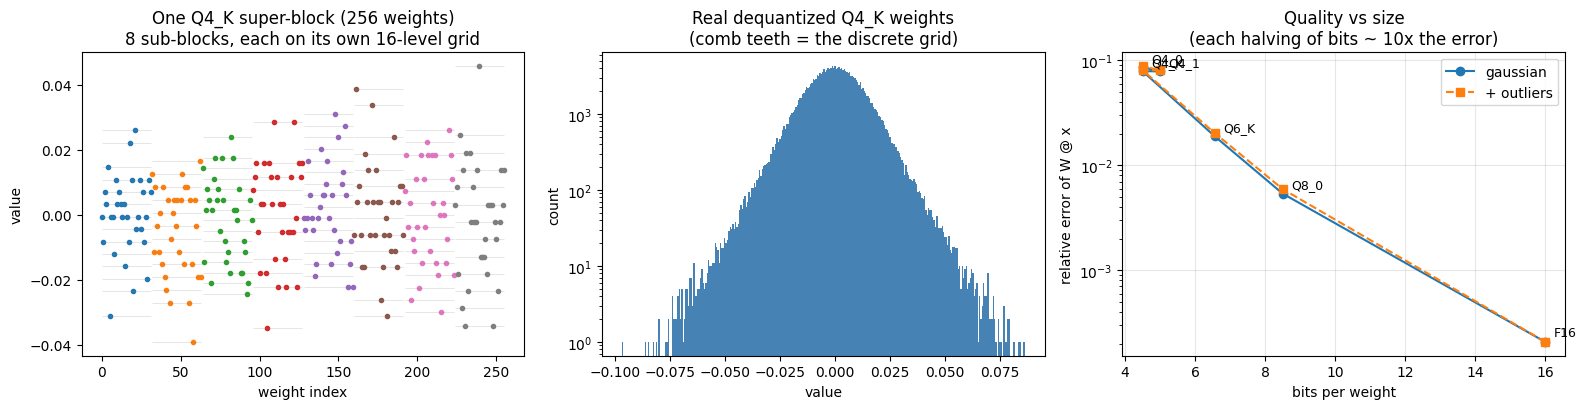

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

# 1) one super-block: the 8 quantization ladders
blk = W.ravel()[:256]
for s in range(8):
    sub = blk[s * 32:(s + 1) * 32]
    ax[0].plot(np.arange(s * 32, (s + 1) * 32), sub, ".", ms=6)
    for lvl in np.unique(sub):
        ax[0].hlines(lvl, s * 32, (s + 1) * 32 - 1, lw=0.4, alpha=0.35, color="gray")
ax[0].set_title("One Q4_K super-block (256 weights)\n8 sub-blocks, each on its own 16-level grid")
ax[0].set_xlabel("weight index"); ax[0].set_ylabel("value")

# 2) the distribution is discrete
ax[1].hist(W.ravel()[:200000], bins=300, color="steelblue")
ax[1].set_title("Real dequantized Q4_K weights\n(comb teeth = the discrete grid)")
ax[1].set_xlabel("value"); ax[1].set_ylabel("count"); ax[1].set_yscale("log")

# 3) error vs bits, from §7.6
names = list(res_g)
ax[2].plot([res_g[k][0] for k in names], [res_g[k][2] for k in names], "o-", label="gaussian")
ax[2].plot([res_o[k][0] for k in names], [res_o[k][2] for k in names], "s--", label="+ outliers")
for k in names:
    ax[2].annotate(k, (res_g[k][0], res_g[k][2]), textcoords="offset points",
                   xytext=(6, 4), fontsize=9)
ax[2].set_yscale("log"); ax[2].set_xlabel("bits per weight")
ax[2].set_ylabel("relative error of W @ x"); ax[2].legend()
ax[2].set_title("Quality vs size\n(each halving of bits ~ 10x the error)")
ax[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

The left panel is the clearest picture of what quantization *is*: within each 32-weight
sub-block the weights snap to one of 16 levels, and each sub-block gets its own spacing and
offset. The middle panel shows the consequence at scale — a weight distribution that used to be
smooth is now a comb.

---

## 8. VRAM Math

Three consumers. Only the first is the one everybody quotes.

```
VRAM  =  weights  +  KV cache  +  compute buffers + CUDA context
```

### 8.1 Weights

$$\text{bytes} = N_{\text{params}} \times \frac{\text{bpw}}{8}$$

A 30.5 B model at 4.86 effective bpw = 17.3 GiB. Note it's the **total** parameters for an MoE,
not the active ones — every expert must be resident.

### 8.2 KV cache — the part that bites you

Every token you've generated keeps a key and a value vector **per layer**, forever (within the
context window):

$$\text{KV bytes} = 2 \times n_{\text{layers}} \times n_{\text{kv heads}} \times d_{\text{head}}
\times n_{\text{ctx}} \times \text{bytes per element}$$

The `2` is K and V. **`n_kv_heads`, not `n_heads`** — this is where GQA pays off.

For `qwen3-coder:30b`: `2 × 48 × 4 × 128 × 2 bytes = 98,304 B per token = 96 KiB/token`.
At 32k context that's **3.0 GiB**; at 128k it's **12.0 GiB** — comparable to the weights.

Without GQA (32 KV heads instead of 4) it would be 768 KiB/token → **96 GiB at 128k.** Long
context on consumer hardware is a GQA story.

> ### ⚠ Hybrid-attention models break this formula
>
> The 2026 generation (Qwen3-Next, Qwen3.5, Qwen3.6, Qwen3-Coder-Next) uses a **hybrid**
> layout: most layers are **Gated DeltaNet** — a linear-attention / state-space layer whose
> state is a **fixed-size matrix that does not grow with context** — and only every 4th layer is
> real ("Gated") attention with a KV cache.
>
> `Qwen3.6-27B` is `16 × (3 × (Gated DeltaNet → FFN) → 1 × (Gated Attention → FFN))`:
> 64 layers, but only **16** of them hold a KV cache. So use `n_layers = 16`, not 64:
>
> `2 × 16 × 4 kv_heads × 256 head_dim × 2 B = 64 KiB/token` → **2 GiB at 32k**, not 8 GiB.
>
> That is the whole point of the architecture, and it is why a 27 B *dense* model can offer a
> 262k context on a 24 GB card. If you plug the full layer count into the formula you will
> over-estimate the KV cache by 4× and talk yourself out of a model that fits.

### 8.3 Compute buffers

Activations, the logits tensor (`vocab × batch`, and 151936 × fp32 is 0.6 MB per sequence),
and the graph scratch space. Typically 0.5–2 GiB. Flash-attention shrinks it. Leave ~1.5 GiB headroom.

### 8.4 The calculator

In [11]:
def vram_estimate(n_params_b, bpw, n_layers, n_kv_heads, head_dim,
                  ctx, kv_bits=16, overhead_gib=1.5, name=""):
    weights = n_params_b * 1e9 * bpw / 8 / 2**30
    kv = 2 * n_layers * n_kv_heads * head_dim * ctx * (kv_bits / 8) / 2**30
    total = weights + kv + overhead_gib
    return dict(name=name, weights=weights, kv=kv, total=total)


def show(rows, budget=24.0):
    print(f"{'model / config':<50}{'weights':>9}{'KV':>8}{'total':>8}   fits 24GB?")
    for r in rows:
        ok = "yes" if r["total"] < budget - 0.6 else ("tight" if r["total"] < budget else "NO")
        print(f"{r['name']:<50}{r['weights']:>8.1f}G{r['kv']:>7.1f}G{r['total']:>7.1f}G   {ok}")


# --- the model we measured, at four context lengths -----------------------
show([vram_estimate(30.5, 4.86, 48, 4, 128, c, name=f"qwen3-coder:30b Q4_K_M  ctx={c//1024}k")
      for c in (8192, 32768, 65536, 131072)])

print()
# --- effect of quantizing the KV cache itself -----------------------------
show([vram_estimate(30.5, 4.86, 48, 4, 128, 131072, kv_bits=b,
                    name=f"qwen3-coder:30b  ctx=128k  KV={lbl}")
      for b, lbl in ((16, "f16"), (8, "q8_0"), (4, "q4_0"))])

model / config                                      weights      KV   total   fits 24GB?
qwen3-coder:30b Q4_K_M  ctx=8k                        17.3G    0.8G   19.5G   yes
qwen3-coder:30b Q4_K_M  ctx=32k                       17.3G    3.0G   21.8G   yes
qwen3-coder:30b Q4_K_M  ctx=64k                       17.3G    6.0G   24.8G   NO
qwen3-coder:30b Q4_K_M  ctx=128k                      17.3G   12.0G   30.8G   NO

model / config                                      weights      KV   total   fits 24GB?
qwen3-coder:30b  ctx=128k  KV=f16                     17.3G   12.0G   30.8G   NO
qwen3-coder:30b  ctx=128k  KV=q8_0                    17.3G    6.0G   24.8G   NO
qwen3-coder:30b  ctx=128k  KV=q4_0                    17.3G    3.0G   21.8G   yes


In [12]:
# --- a survey of models on a 24 GB card ----------------------------------
# (n_params_B, bpw, n_layers, n_kv_heads, head_dim, ctx, label)
CATALOG = [
    # NOTE: n_layers here means "layers that hold a KV cache". For hybrid-attention
    # models (Qwen3.5/3.6/Next) that is only 1 in 4 layers — see the warning in §8.2.
    ( 8.0, 4.86, 32,  8, 128, 32768, "Llama-3.1-8B         Q4_K_M  32k"),
    ( 8.0, 8.50, 32,  8, 128, 32768, "Llama-3.1-8B         Q8_0    32k"),
    ( 7.6, 4.86, 28,  4, 128, 32768, "Qwen2.5-Coder-7B     Q4_K_M  32k"),
    ( 7.6, 8.50, 28,  4, 128, 32768, "Qwen2.5-Coder-7B     Q8_0    32k"),
    (14.8, 4.86, 48,  8, 128, 32768, "Qwen2.5-Coder-14B    Q4_K_M  32k"),
    (14.8, 8.50, 48,  8, 128, 16384, "Qwen2.5-Coder-14B    Q8_0    16k"),
    (32.8, 4.86, 64,  8, 128, 16384, "Qwen2.5-Coder-32B    Q4_K_M  16k"),
    (32.8, 4.86, 64,  8, 128, 32768, "Qwen2.5-Coder-32B    Q4_K_M  32k"),
    (32.8, 5.50, 64,  8, 128, 16384, "Qwen2.5-Coder-32B    Q5_K_M  16k"),
    (32.8, 4.25, 64,  8, 128, 32768, "Qwen2.5-Coder-32B    IQ4_XS  32k"),
    (30.5, 4.86, 48,  4, 128, 32768, "Qwen3-Coder-30B-A3B  Q4_K_M  32k"),
    (23.6, 4.86, 40,  8, 128, 32768, "Devstral-Small-24B   Q4_K_M  32k"),
    (70.6, 4.86, 80,  8, 128,  8192, "Llama-3.3-70B        Q4_K_M   8k"),
    (70.6, 2.63, 80,  8, 128,  8192, "Llama-3.3-70B        Q2_K     8k"),
]
show([vram_estimate(*c[:6], name=c[6]) for c in CATALOG])

model / config                                      weights      KV   total   fits 24GB?
Llama-3.1-8B         Q4_K_M  32k                       4.5G    4.0G   10.0G   yes
Llama-3.1-8B         Q8_0    32k                       7.9G    4.0G   13.4G   yes
Qwen2.5-Coder-7B     Q4_K_M  32k                       4.3G    1.8G    7.5G   yes
Qwen2.5-Coder-7B     Q8_0    32k                       7.5G    1.8G   10.8G   yes
Qwen2.5-Coder-14B    Q4_K_M  32k                       8.4G    6.0G   15.9G   yes
Qwen2.5-Coder-14B    Q8_0    16k                      14.6G    3.0G   19.1G   yes
Qwen2.5-Coder-32B    Q4_K_M  16k                      18.6G    4.0G   24.1G   NO
Qwen2.5-Coder-32B    Q4_K_M  32k                      18.6G    8.0G   28.1G   NO
Qwen2.5-Coder-32B    Q5_K_M  16k                      21.0G    4.0G   26.5G   NO
Qwen2.5-Coder-32B    IQ4_XS  32k                      16.2G    8.0G   25.7G   NO
Qwen3-Coder-30B-A3B  Q4_K_M  32k                      17.3G    3.0G   21.8G   yes
Devstral-Smal

In [13]:
# --- the mid-2026 shelf (§12), including hybrid-attention models ----------
# For hybrid models pass the number of ATTENTION layers, not the total layer count.
SHELF_2026 = [
    # (params_B, bpw, kv_layers, kv_heads, head_dim, ctx, label)
    (30.5, 4.86, 48, 4, 128, 32768, "Qwen3-Coder-30B-A3B  Q4_K_M  32k   (48/48 attn)"),
    (27.0, 4.86, 16, 4, 256, 32768, "Qwen3.6-27B dense    Q4_K_M  32k   (16/64 attn)"),
    (27.0, 4.86, 16, 4, 256, 262144, "Qwen3.6-27B dense    Q4_K_M  262k! (16/64 attn)"),
    (27.0, 4.86, 64, 4, 256, 32768, "Qwen3.6-27B  IF it were all-attention  32k"),
    (35.0, 4.86, 16, 4, 256, 32768, "Qwen3.6-35B-A3B      Q4_K_M  32k"),
    (30.0, 4.86, 48, 4, 128, 32768, "GLM-4.7-Flash 30B    Q4_K_M  32k"),
    (26.0, 4.86, 48, 4, 128, 32768, "Gemma 4 26B-A3.8B    Q4_K_M  32k"),
    (23.6, 4.86, 40, 8, 128, 32768, "Devstral-Small-24B   Q4_K_M  32k"),
    ( 3.0, 4.86, 12, 4, 128, 16384, "DeepSeek-OCR 3B      Q4_K_M  16k"),
    ( 0.6, 8.50, 28, 8,  64,  8192, "Qwen3-Embedding-0.6B Q8_0     8k"),
]
show([vram_estimate(*c[:6], name=c[6]) for c in SHELF_2026])

print("\nNote row 3 vs row 4: hybrid attention is the difference between a 262k context"
      "\nfitting on this card and not fitting at all.")

model / config                                      weights      KV   total   fits 24GB?
Qwen3-Coder-30B-A3B  Q4_K_M  32k   (48/48 attn)       17.3G    3.0G   21.8G   yes
Qwen3.6-27B dense    Q4_K_M  32k   (16/64 attn)       15.3G    2.0G   18.8G   yes
Qwen3.6-27B dense    Q4_K_M  262k! (16/64 attn)       15.3G   16.0G   32.8G   NO
Qwen3.6-27B  IF it were all-attention  32k            15.3G    8.0G   24.8G   NO
Qwen3.6-35B-A3B      Q4_K_M  32k                      19.8G    2.0G   23.3G   yes
GLM-4.7-Flash 30B    Q4_K_M  32k                      17.0G    3.0G   21.5G   yes
Gemma 4 26B-A3.8B    Q4_K_M  32k                      14.7G    3.0G   19.2G   yes
Devstral-Small-24B   Q4_K_M  32k                      13.4G    5.0G   19.9G   yes
DeepSeek-OCR 3B      Q4_K_M  16k                       1.7G    0.4G    3.6G   yes
Qwen3-Embedding-0.6B Q8_0     8k                       0.6G    0.4G    2.5G   yes

Note row 3 vs row 4: hybrid attention is the difference between a 262k context
fitting on th

### 8.5 Validating the model against reality

The estimates above are worth exactly as much as their agreement with a real GPU. Here is what
I measured on the 3090, same model, only `num_ctx` and the KV dtype varying:

| context | KV type | predicted KV | `ollama ps` SIZE | `nvidia-smi` used | placement | **gen tok/s** |
|---|---|---|---|---|---|---|
| 8 192 | f16 | 0.75 GiB | 19 GB | 18 721 MiB | 100% GPU | **186.6** |
| 32 768 | f16 | 3.0 GiB | 21 GB | 21 047 MiB | 100% GPU | **185.4** |
| 32 768 | q8_0 | 1.5 GiB | 20 GB | 19 613 MiB | 100% GPU | **173.5** |
| 131 072 | f16 | 12.0 GiB | 31 GB | 23 133 MiB | **25% CPU** / 75% GPU | **51.1** |
| 131 072 | q8_0 | 6.0 GiB | 25 GB | 23 137 MiB | **8% CPU** / 92% GPU | **101.6** |

The formula predicts 8k→32k costs +2.25 GiB; measured 21 047 − 18 721 = 2 326 MiB = **2.27 GiB**.
Within 1%.

The rows that matter are the last two. **The instant any part of the model spills to system RAM,
throughput collapses** — 185 → 51 tok/s, a 3.6× penalty, because those layers now run on the CPU
and stream over PCIe. Quantizing the KV cache to `q8_0` halves it, pulls most of it back onto the
GPU, and recovers 2× (51 → 102 tok/s).

**The practical rule: never let `ollama ps` show anything other than `100% GPU`.** If it does,
reduce context or drop a quant level. A smaller quant fully on the GPU beats a bigger one that spills.

To reproduce:

```bash
ollama ps                    # SIZE + PROCESSOR column
nvidia-smi --query-gpu=memory.used,memory.total --format=csv

# enable KV cache quantization (needs flash attention)
OLLAMA_FLASH_ATTENTION=1 OLLAMA_KV_CACHE_TYPE=q8_0 ollama serve

# llama.cpp equivalent
llama-server -m model.gguf -ngl 99 -c 32768 --flash-attn \
             --cache-type-k q8_0 --cache-type-v q8_0
```

> Caveat: measure a *warm* run. My first call after a server restart reported 3.5 tok/s because
> weights were still being paged in from disk. The second call: 101 tok/s.

---

## 9. What Runs on an RTX 3090 (24 GB)

Assumes 24 GB with ~1 GB used by the desktop, `Q4_K_M` unless stated, and full GPU offload.

Weights in **GiB** (what `nvidia-smi` counts) — vendors quote GB, which is 7% larger.

| Model | Quant | Weights | Realistic ctx | Speed (tok/s) | Verdict |
|---|---|---|---|---|---|
| Qwen2.5-Coder-1.5B | Q8_0 | 1.5 GiB | 128k | 200+ | autocomplete / FIM only |
| Qwen2.5-Coder-7B | Q8_0 | 7.5 GiB | 64k | 55–70 | strong for its size |
| Llama-3.1-8B | Q8_0 | 7.9 GiB | 64k | 50–65 | general chat |
| Qwen2.5-Coder-14B | Q8_0 | 14.6 GiB | 32k | 30–40 | very good |
| **Qwen3-Coder-30B-A3B** | **Q4_K_M** | **17.3 GiB** | **32k** | **185** ✅measured | **best speed/quality on 24 GB** |
| Devstral-Small-24B | Q4_K_M | 13.4 GiB | 64k | 30–38 | built for agentic coding |
| **Qwen2.5-Coder-32B** | **Q4_K_M** | **18.6 GiB** | **16–24k** | **28–34** | **best raw quality that fits** |
| Qwen2.5-Coder-32B | IQ4_XS | 16.2 GiB | 32k | 26–32 | same quality, more context |
| Qwen2.5-Coder-32B | Q5_K_M | 21.0 GiB | ~4k | 25–30 | too tight, don't |
| gpt-oss-20b | MXFP4 | ~11.3 GiB | 64k | 90–120 | MoE, fast, tool-friendly |
| DeepSeek-R1-Distill-Qwen-32B | Q4_K_M | 18.6 GiB | 16k | 28–34 | reasoning, verbose |
| Llama-3.3-70B | IQ2_XXS | 16.9 GiB | 8k | 12–16 | degraded; prefer 32B@Q4 |
| gpt-oss-120b | MXFP4 | ~59 GiB | — | 15–25 | only via MoE CPU offload (§10) |

Speeds other than the measured row are typical figures for a 3090; treat them as ±20% and
benchmark your own (§13 has the code).

**The three defaults I'd actually set on a 3090:**

- **Fast agentic coding / aider:** `Qwen3-Coder-30B-A3B` (Q4_K_M). 185 tok/s at 32k, measured.
  MoE means it's a 30 B model that runs at 3 B speed.
- **Maximum single-shot quality:** `Qwen3.6-27B` (Q4_K_M) — dense, multimodal, hybrid
  attention so its KV cache is tiny for a 27 B model.
- **Long context / lots of files open:** any of the hybrid-attention models above with
  `--cache-type-k q8_0`.

> **This table is the 2025-era shelf.** §12 has the mid-2026 landscape — `Qwen3.6-27B`,
> `GLM-4.7-Flash` and `Gemma 4 26B-A3.8B` all land in the same VRAM class and are better
> than the Qwen2.5-Coder line kept here for reference. The **arithmetic** below doesn't
> change; only the names do.

### Things that change the answer

- **`nvidia-smi` before you load.** A browser + desktop can hold 1–2 GB. `sudo systemctl isolate
  multi-user.target` frees ~500 MB if you're desperate.
- **Flash attention** (`--flash-attn` / `OLLAMA_FLASH_ATTENTION=1`) cuts the attention scratch
  buffer. Basically free, turn it on.
- **KV cache quantization** to `q8_0` halves the KV cache at negligible quality cost.
  `q4_0` KV is a quarter but is noticeably lossy — measure before trusting it.
- **The 3090's real constraint is bandwidth, not FLOPs**: 936 GB/s. Token generation is
  memory-bound, so tok/s ≈ bandwidth ÷ bytes-read-per-token. A 17.3 GiB dense model can't exceed
  ~50 tok/s; the reason the 30B-A3B hits 185 is that it only reads its 8 active experts (~2 GiB)
  per token.
- **NVLink / two 3090s**: llama.cpp splits layers across GPUs with `--split-mode layer`. A second
  3090 gets you 70 B @ Q4_K_M. `--split-mode row` is usually slower without NVLink.

---

## 10. MoE Models and CPU Offload

`Qwen3-Coder-30B-A3B` is **30.5 B total, 3.3 B active**: 128 experts per layer, 8 routed per token.

| | dense 30 B @ Q4_K_M | MoE 30B-A3B @ Q4_K_M |
|---|---|---|
| VRAM for weights | 17.3 GiB | 17.3 GiB (**all** experts must be resident) |
| bytes read per generated token | ~17.3 GiB | ~2 GiB (8 of 128 experts) |
| ceiling at the 3090's 936 GB/s | ~50 tok/s | ~400 tok/s |
| observed generation speed | ~30–35 tok/s (typical) | **185 tok/s** (measured, §8.5) |
| quality | ~30 B dense | between a 14 B and a 30 B dense, with better breadth |

This is why MoE is *the* format for local inference: you pay for a 30 B model in **memory** but a
3 B model in **bandwidth**, and token generation is bandwidth-bound. It is also why the §9 table
has the 30B-A3B at 5–6× the tok/s of the dense 32 B despite similar file sizes.

### The trick that makes 120 B models runnable on 24 GB

Experts are read sparsely, so put **only the experts** in system RAM and keep attention +
router + norms on the GPU:

```bash
# llama.cpp: keep everything on GPU except tensors matching "exps"
llama-server -m gpt-oss-120b-MXFP4.gguf -ngl 99 -c 16384 \
             --flash-attn -ot "exps=CPU"

# newer, friendlier flag — offload N MoE layers' experts to CPU
llama-server -m model.gguf -ngl 99 --n-cpu-moe 20 -c 16384
```

`-ot` / `--override-tensor` takes a regex over tensor names (that's why §7.7's tensor-name dump is
practically useful) and pins matches to a backend. Attention is dense and latency-critical → GPU.
Experts are sparse and huge → CPU RAM, which on a dual-channel DDR5 desktop still gives ~60 GB/s.

Result: `gpt-oss-120b` (63 GB) runs at 15–25 tok/s on a 24 GB card with 64 GB of RAM. Not fast,
but it *runs*, and that's a 120 B model.

---

## 11. How to Read a Model Name

### 11.1 The Ollama form

```
                    qwen2.5-coder:32b-instruct-q4_K_M
                    └──┬──┘└──┬─┘ └┬┘ └───┬──┘ └──┬─┘
                       │      │    │      │       └── quantization (default: Q4_K_M)
                       │      │    │      └────────── post-training (instruct / base / thinking)
                       │      │    └───────────────── parameter count
                       │      └────────────────────── domain specialization
                       └───────────────────────────── family + version
```

Everything after `:` is a **tag**. `qwen2.5-coder:32b` is shorthand — Ollama resolves it to
`32b-instruct-q4_K_M`. `qwen2.5-coder` alone resolves to `:latest`, which is usually the **7B**.
Always pin the size and, for reproducibility, the quant:

```bash
ollama pull qwen2.5-coder:32b                    # -> 32b-instruct-q4_K_M, 19 GB
ollama pull qwen2.5-coder:32b-instruct-q8_0      # 35 GB — will NOT fit on a 3090
ollama pull qwen2.5-coder:7b-base-q8_0           # base model, for fill-in-the-middle
```

| token | meaning |
|---|---|
| `base` | raw pretrained. No chat template. Use for FIM/autocomplete. |
| `instruct` / `it` | instruction-tuned + chat template. What you want 95% of the time. |
| `chat` | older name for the same idea |
| `thinking` / `R1` / `reasoning` | emits a `<think>` block before answering |
| `coder` / `code` | continued-pretrained on code |
| `A3B` / `A22B` | MoE: **A**ctive parameters (`30B-A3B` = 30 B total, 3 B active) |
| `distill` | a small model trained on a big model's outputs |
| `2507`, `0528` | release date (YYMM/MMDD) — Qwen and DeepSeek use these for revisions |

### 11.2 The HuggingFace form

```
Qwen/Qwen3-Coder-30B-A3B-Instruct
└─┬─┘ └──────────────┬───────────┘
 org                model id

bartowski/Qwen2.5-Coder-32B-Instruct-GGUF     ← a re-publisher of quantized builds
unsloth/Qwen3-Coder-30B-A3B-Instruct-GGUF
```

and inside such a repo, the files:

```
Qwen2.5-Coder-32B-Instruct-Q4_K_M.gguf         19.9 GB
Qwen2.5-Coder-32B-Instruct-Q5_K_M.gguf         23.3 GB
Qwen2.5-Coder-32B-Instruct-IQ4_XS.gguf         17.7 GB
Qwen2.5-Coder-32B-Instruct-Q8_0-00001-of-00002.gguf   ← split, needs both parts
```

The names to trust for GGUF quants: **`bartowski`** (imatrix, full ladder of quants),
**`unsloth`** (their "UD" dynamic quants pick per-tensor bits more aggressively),
**`mradermacher`** (enormous coverage), and the model author's own `-GGUF` repo when it exists.

```bash
hf download bartowski/Qwen2.5-Coder-32B-Instruct-GGUF \
    --include "*Q4_K_M*.gguf" --local-dir ./models
```

### 11.3 Model size ≈ file size

`params × bpw / 8`. A "32b" model at Q4_K_M is `32.8e9 × 4.86 / 8 = 19.9 GB`. You can do this
in your head: **at Q4_K_M, GB ≈ 0.6 × billions of parameters.** At Q8_0, `GB ≈ 1.06 × B`.

---

# 12. The Open-Weight Model Landscape

> **Status: July 2026.** This field moves in weeks. Architecture facts (parameter counts,
> layer layouts, context lengths, licenses) come from the model cards and are stable.
> **Benchmark numbers are vendor-reported** and every lab reports the configuration that
> flatters it — treat them as ordering hints, not measurements. The only numbers in this
> notebook I stand behind absolutely are the ones §8.5 measured on this machine.

## 12.1 Who Makes What

| Lab | Family | License | Local story |
|---|---|---|---|
| **Alibaba** | Qwen | mostly Apache-2.0 | ⭐ the deepest lineup at every size; the default for consumer GPUs |
| **DeepSeek** | V3 / V4 / R1 / Coder / Math / OCR | MIT (most) | frontier models are enormous; the *specialists* are small and useful |
| **Z.ai (Zhipu)** | GLM | MIT | flagship is huge, but `GLM-4.7-Flash` is a genuinely great 24 GB model |
| **Google** | Gemma | Apache-2.0-ish (Gemma terms) | best small multilingual + vision; strongest "safe default" |
| **Mistral** | Mistral / Devstral / Codestral | Apache-2.0 & non-commercial | Devstral is purpose-built for agentic editing |
| **OpenAI** | `gpt-oss` | Apache-2.0 | native MXFP4, excellent tool-calling |
| **Meta** | Llama | Llama Community License | still everywhere in tooling; no longer the quality leader |
| **Moonshot** | Kimi | custom | frontier scale only — see §12.9 |

## 12.2 The Three Size Tiers

Almost every model released in 2026 falls into one of three tiers, and only one of them
concerns you on a 24 GB card:

| Tier | Total params | Examples (2026) | On a 3090? |
|---|---|---|---|
| **Frontier** | 400 B – 2.8 T | Kimi K3 (2.8T-A104B), DeepSeek-V4-Pro (1.6T-A49B), GLM-5.2 (753B), Qwen3.5-397B-A17B | ❌ never — see §12.9 |
| **Prosumer** | 80 – 300 B | Qwen3-Coder-Next (80B-A3B), GLM-4.5-Air (106B-A12B), DeepSeek-V4-Flash (284B-A13B), gpt-oss-120b | ⚠️ only with MoE CPU offload (§10) |
| **Local** | 2 – 40 B | Qwen3.6-27B, Gemma 4 31B / 26B-A3.8B, GLM-4.7-Flash (30B-A3.6B), Qwen3-Coder-30B-A3B, Mistral Small 24B | ✅ this is your shelf |

The good news of 2026 is that the **local tier got dramatically better**, because hybrid
attention (§8) and aggressive MoE let a 27–35 B model behave like last year's 200 B one.

## 12.3 Qwen — the Family Tree

Qwen is not one model, it's a **product line**. This is the part people most often get lost in,
so here is the whole tree. Sizes marked ✅ fit a 24 GB card at Q4.

### Mainline text (the "just a chat model" branch)

| Series | Released | Sizes | Notes |
|---|---|---|---|
| Qwen2.5 | 2024 | 0.5 – 72 B dense | the old reliable; still fine, now superseded |
| **Qwen3** | 2025 | 0.6/1.7/4/8/14/32 B dense, 30B-A3B, 235B-A22B | introduced **hybrid thinking** (`/think`, `/no_think` in one model) |
| **Qwen3.5** | Feb 2026 | 0.8/2/4/9/27 B, 35B-A3B, 122B-A10B, 397B-A17B | first mainline on **Gated DeltaNet hybrid attention**, 262k native |
| **Qwen3.6** | Apr 2026 | **27 B dense** ✅, **35B-A3B** ✅ | current frontier of the *local* tier; natively multimodal (image input) |

**`qwen3:32b-instruct` — what is it actually for?** You asked specifically. It's the 2025
dense generalist: strong instruction-following, solid multilingual, good structured output
(JSON/tool calls), reasonable at code but not a specialist. Its niche in 2026 is **"one dense
model that does everything predictably"** — dense models are more consistent than MoE at
low temperature, which matters for data extraction, classification and templated generation.
For *coding* it has been superseded by Qwen3.6-27B; for *general assistant* work it's still
perfectly good and very well supported by tooling. If you're downloading fresh today, take
Qwen3.6-27B instead — same VRAM class, much better.

### Code

| Series | Sizes | Notes |
|---|---|---|
| Qwen2.5-Coder | 0.5/1.5/3/7/14/32 B | the `base` variants do **fill-in-the-middle** — still the best FIM option |
| Qwen3-Coder | **30B-A3B** ✅, 480B-A35B | ✅ **the model measured in this notebook**, 256k ctx, strong tool-calling |
| **Qwen3-Coder-Next** | 80B-A3B | Feb 2026; 512 experts, 10 active; hybrid attention; ~46 GB at Q4 → offload only |

### Everything else — the branches people forget exist

| Branch | Sizes | What it's for |
|---|---|---|
| **Qwen3-Embedding** | 0.6 / 4 / 8 B | text embeddings for RAG. The 0.6 B is excellent and tiny |
| **Qwen3-Reranker** | 0.6 / 4 / 8 B | cross-encoder reranking — the *second* stage of a good RAG pipeline |
| **Qwen3-VL** | 2/4/8/30/32/235 B | vision-language: screenshots, documents, charts, video, GUI agents |
| **Qwen3-VL-Embedding / Reranker** | 2 / 8 B | Jan 2026; multimodal retrieval — search images and document scans by text |
| **Qwen3-Omni** / Qwen3.5-Omni | 30B-A3B | text + audio + image + video **in**, text + speech **out**, one pass |
| **Qwen3Guard** | 0.6 / 4 / 8 B | safety classification. `-Gen` scores a finished response; `-Stream` classifies token-by-token during generation |
| **Qwen3-TTS** | 0.6 / 1.7 B | speech synthesis + voice cloning, 10 languages |
| **Qwen-Image / 2.0** | 20 B → 7 B | text-to-image **and** editing in one model; unusually good at rendering text in images |
| **QwQ / Qwen2-Math** | 32 B / 1.5–72 B | older reasoning + math specialists, folded into the thinking modes of Qwen3+ |

**The practical point:** for a RAG system you don't want one model, you want three from this
table — `Qwen3-Embedding-0.6B` for retrieval, `Qwen3-Reranker-0.6B` for precision, and a
27–30 B generator. All three together fit on your 3090 with room to spare, and the two small
ones cost almost nothing to keep resident.

## 12.4 DeepSeek — Where It Actually Wins

DeepSeek's flagships are **research-grade and enormous**; its specialists are small and
genuinely best-in-class. Knowing which is which is the whole game.

| Model | Size | License | For what |
|---|---|---|---|
| DeepSeek-V4-Pro | 1.6 T-A49B | open weights | frontier general/agentic. ~1 M ctx. Datacenter only |
| DeepSeek-V4-Flash | 284B-A13B | open weights | the "practical" one — still ~142 GB at Q4 |
| DeepSeek-V3 / V3.1 | 671B-A37B | MIT | the model that made MoE mainstream |
| **DeepSeek-R1** | 671B-A37B | MIT | RL-trained reasoning. **This is the real R1** |
| DeepSeek-R1-Distill-Qwen | 1.5/7/14/32 B ✅ | MIT | ⚠️ **Qwen/Llama fine-tunes, not R1** — see the trap below |
| DeepSeek-Coder-V2-Lite | 16B-A2.4B ✅ | MIT | ageing but very fast; 128k ctx |
| **DeepSeek-OCR** | 3 B ✅ | MIT | ⭐ document/chart/formula OCR. Punches far above 3 B |
| DeepSeek-Math / Prover | 7 B ✅ | MIT | formal maths, Lean proof generation |
| DeepSeek-VL2 / Janus | 1–27 B | MIT | vision-language / unified understanding+generation |

**What DeepSeek is better at than Qwen**, concretely:

- **Deliberate mathematical and algorithmic reasoning.** R1-lineage models were RL-trained to
  produce long chains of thought. For "derive the recurrence and prove the complexity bound",
  an R1-distill beats a similarly-sized instruct model.
- **Documents.** `DeepSeek-OCR` (3 B!) is the best open document-understanding model you can
  run locally — scanned PDFs, tables, chemical/mathematical notation. Nothing from Qwen at
  that size competes.
- **Formal proof.** `DeepSeek-Prover` is essentially unrivalled in open weights.

**What it's worse at:** breadth of sizes, tool-calling reliability in agent loops, and
speed-per-quality at the 30 B mark. For *interactive coding* on a 3090, Qwen wins.

> ### ⚠️ The `deepseek-r1:32b` trap
> `deepseek-r1:32b` is **DeepSeek-R1-Distill-Qwen-32B** — Qwen2.5-32B fine-tuned on R1's
> reasoning traces. It is a Qwen model wearing a DeepSeek name. It's decent, but it is *not*
> what the R1 paper benchmarked, and the real R1 is 671 B (~400 GB at Q4). Distills are also
> **verbose**: they burn 3–10× the output tokens on `<think>` blocks, which is fine for a hard
> one-shot problem and miserable inside an agentic edit loop.

## 12.5 GLM (Z.ai / Zhipu) — the Agentic Specialist

You asked what GLM solves that the others don't. The honest answer is **long-horizon agentic
work**: multi-step tasks where the model must keep a plan, call tools repeatedly, recover from
a failed command, and not lose the thread over hundreds of turns.

| Model | Size | License | Fits 24 GB? |
|---|---|---|---|
| GLM-5.2 | 753B MoE, 1 M ctx | **MIT** | ❌ |
| GLM-5 | 745B-A40B, 200k ctx | open weights | ❌ |
| GLM-4.5-Air | 106B-A12B | MIT | ⚠️ offload |
| **GLM-4.7-Flash** | **30B-A3.6B, 200k ctx** | open weights | ✅ **~17 GB at Q4_K_M** |

**Where GLM genuinely differs from Qwen at the same size:**

- **Tool-call discipline.** GLM models are trained hard on multi-turn function calling. In
  practice they emit fewer malformed tool calls and recover better after an error result —
  exactly the failure mode that makes local models frustrating in Cline/OpenHands/aider.
- **Long-horizon coherence.** They hold a plan across many steps instead of re-deriving it.
- **Context length at the local tier.** 200k on `GLM-4.7-Flash` vs 256k on Qwen3-Coder-30B —
  comparable, but GLM degrades more gracefully deep into the window.

**Where it does *not* win:** raw single-shot code quality (Qwen3.6-27B is stronger), FIM
autocomplete (no good small variant), and ecosystem/tooling maturity.

> Note there is **no GLM-5-Air**. Z.ai shipped Air at the 4.5 generation and then went
> frontier-only, so `GLM-4.7-Flash` is the current local entry point. Don't wait for an Air 5.

## 12.6 Gemma (Google) — the Safe Generalist

| Model | Size | Notes |
|---|---|---|
| Gemma 3 | 1/4/12/**27 B** | Mar 2025. Multimodal, 128k ctx, 140+ languages |
| **Gemma 4** | E2B, E4B, **26B-A3.8B MoE**, **31 B dense** | Apr 2026, Apache-2.0 |

**About `gemma3:27b` specifically** — it was an excellent general-purpose/vision model and is
still fine, but Gemma 4 supersedes it decisively; Google reports the 31 B at 80.0% on
LiveCodeBench v6 versus 29.1% for Gemma 3 27B, and similar step-changes on math and tool use.
If you have `gemma3:27b` on disk, replace it.

**Gemma's actual niche** is not benchmark-topping — it's being the **best-behaved** model in
the local tier:

- **Multilingual breadth** (140+ languages) far beyond Qwen's practical range.
- **Vision that works on ordinary photos**, not just documents and screenshots.
- **Instruction-following without drama** — low refusal noise, predictable formatting, and
  genuinely permissive licensing for a Google product.
- **`Gemma 4 26B-A3.8B` is the interesting one for you**: MoE, ~3.8 B active, so it runs at
  small-model speed while Google claims ~97% of the dense 31 B's quality. That's the same
  bargain Qwen3-Coder-30B-A3B offers, applied to general/vision work.

Weakness: agentic coding. Gemma is a strong *assistant*, not a strong *agent*.

## 12.7 The Rest, Briefly

| Model | Size | Why you'd pick it |
|---|---|---|
| **Devstral-Small** (Mistral) | 23.6 B ✅ | purpose-built for SWE-bench-style **edit loops**; excellent with aider |
| **Mistral Small 3.2** | 24 B ✅ | polished, low-drama daily assistant; strong European languages |
| Codestral | 22 B ✅ | strong FIM — but **non-commercial license**, check before work use |
| **gpt-oss-20b** (OpenAI) | 21B-A3.6B ✅ | native **MXFP4** (~11 GiB), fast, very good tool-calling, Apache-2.0 |
| gpt-oss-120b | 117B-A5.1B | ⚠️ offload only (§10) |
| Llama 3.3 / 4 (Meta) | 70 B / MoE | broad tooling support; quality no longer competitive at 24 GB |
| StarCoder2 / granite-code | 3–34 B ✅ | permissively-trained data — matters if provenance is a compliance issue |
| CodeLlama | 7–70 B | **obsolete.** Qwen2.5-Coder-7B beats CodeLlama-34B |

## 12.8 What To Actually Download

Your 3090 has room for roughly **one 27–32 B model at a time**, plus a couple of small
always-resident ones. Pick by task, not by leaderboard.

| Your task | Download this | Q4 size | Why |
|---|---|---|---|
| **Agentic coding** (aider, Cline) | `Qwen3-Coder-30B-A3B-Instruct` | 17.3 GiB | ✅ measured 185 tok/s here. MoE speed is what makes agent loops bearable |
| **Best single-shot code quality** | `Qwen3.6-27B` | ~17 GiB | current top of the local tier; dense, multimodal, 262k ctx |
| **Agentic + tool-heavy, GLM flavour** | `GLM-4.7-Flash` | ~17 GiB | best tool-call discipline at this size |
| **General assistant + vision** | `Gemma 4 26B-A3.8B` | ~15 GiB | fast MoE, 140+ languages, well-behaved |
| **Hard maths / algorithms** | `DeepSeek-R1-Distill-Qwen-32B` | 18.6 GiB | long deliberate CoT; expect verbosity |
| **Documents, scans, charts** | `DeepSeek-OCR` (3 B) | ~2 GiB | ⭐ best-in-class per byte; keep it resident |
| **Editor autocomplete (FIM)** | `Qwen2.5-Coder-1.5B-base` | ~1.5 GiB | run *alongside* your big model |
| **RAG retrieval** | `Qwen3-Embedding-0.6B` + `Qwen3-Reranker-0.6B` | ~1.5 GiB both | two-stage retrieval beats a bigger single embedder |
| **Screenshots / GUI agents** | `Qwen3-VL-8B` | ~5 GiB | leaves room for a text model too |

### A sane 3090 loadout

```
always resident (~5 GiB):   Qwen3-Embedding-0.6B + Qwen3-Reranker-0.6B
                            + Qwen2.5-Coder-1.5B-base (FIM)
swap one of (~17 GiB):      Qwen3-Coder-30B-A3B   ← agentic coding
                            Qwen3.6-27B           ← quality / vision / general
                            GLM-4.7-Flash         ← tool-heavy agents
                            DeepSeek-OCR 3B       ← document days (tiny, add anytime)
```

That leaves ~2 GiB of headroom for KV cache growth and the desktop. Don't try to keep two
27 B models loaded — the moment you spill, you lose 3.6× (§8.5).

### Try before you commit to a 17 GiB download

Every one of these is a multi-gigabyte download. Test the *family* with a small sibling first:

```bash
# 30 seconds instead of 30 minutes — does this family follow your prompt style?
llama-server -hf unsloth/Qwen3.6-27B-GGUF:UD-Q4_K_XL   # or a 4B sibling first
```

## 12.9 What Does **Not** Fit (and the honest arithmetic)

You're right that Kimi K3 is out of reach — but it's worth seeing *how far* out, because the
same arithmetic tells you when offload is worth trying and when it isn't.

| Model | Total params | Active | Weights @ Q4 | vs your 24 GiB |
|---|---|---|---|---|
| **Kimi K3** | 2.8 T-A104B | 104 B | **~1.4 TB** | 58× over. Not a hardware problem you can solve |
| DeepSeek-V4-Pro | 1.6 T-A49B | 49 B | ~800 GB | 33× over |
| GLM-5.2 | 753 B | ~40 B | ~380 GB | 16× over |
| Qwen3.5-397B-A17B | 397 B | 17 B | ~200 GB | 8× over |
| DeepSeek-V4-Flash | 284B-A13B | 13 B | ~142 GB | 6× over |
| gpt-oss-120b | 117B-A5.1B | 5.1 B | ~59 GiB | ⚠️ **offload works** — 15–25 tok/s |
| GLM-4.5-Air | 106B-A12B | 12 B | ~53 GiB | ⚠️ offload, slow |
| Qwen3-Coder-Next | 80B-A3B | 3 B | ~46 GiB | ⚠️ **offload works well** — only 3 B active |

**The rule for offload (§10):** what matters is not total size but **active parameters and how
much you must stream from system RAM per token.** `Qwen3-Coder-Next` at 80B-A3B is 46 GiB on
disk but touches ~2 GiB per token, so pushing experts to CPU RAM costs you maybe 3–4×, not
50×. `Kimi K3` at A104B would stream ~50 GiB per token over a ~60 GB/s bus — about one token
per second, before you even find 1.4 TB of RAM.

```bash
# the realistic stretch goal on a 3090 + 64 GB RAM:
llama-server -m Qwen3-Coder-Next-UD-Q4_K_XL.gguf \
             -ngl 99 --n-cpu-moe 28 -c 32768 --flash-attn \
             --cache-type-k q8_0 --cache-type-v q8_0
```

Start `--n-cpu-moe` high (~30) and walk it down until `nvidia-smi` is near 23 GiB. Each layer
you move back to the GPU is free speed.

> **Reality check:** a 30 B model fully on the GPU at 185 tok/s will get more work done in an
> agent loop than an 80 B model at 12 tok/s, because agent loops retry. Fit beats size.

## 12.10 A note on tooling: you don't need Ollama

Ollama is a convenience wrapper around llama.cpp with a model registry — it is **not** a Meta
product (Meta makes *Llama*, the model; Ollama is an unrelated company, confusingly named).
But your instinct is sound: it hides flags, defaults the context window too low, re-tags models
in ways that obscure the actual quant, and adds a daemon you didn't ask for.

**llama.cpp alone does everything in this notebook**, and since 2024 it downloads from
HuggingFace itself — no registry, no daemon, no conversion:

```bash
# pull + run in one command; -hf takes  <user>/<repo>:<quant-substring>
llama-server -hf unsloth/Qwen3.6-27B-GGUF:UD-Q4_K_XL \
             -ngl 99 -c 32768 --flash-attn \
             --cache-type-k q8_0 --cache-type-v q8_0 \
             --host 127.0.0.1 --port 8080 --jinja

# one-shot from the terminal, no server
llama-cli -hf unsloth/Qwen3.6-27B-GGUF:UD-Q4_K_XL -ngl 99 -p "explain this diff" --no-cnv
```

Files land in `~/.cache/llama.cpp/` with their real names, so you always know which quant you
are running. Point aider (§15) at `http://127.0.0.1:8080/v1` instead of Ollama:

```bash
export OPENAI_API_BASE=http://127.0.0.1:8080/v1
export OPENAI_API_KEY=dummy          # llama-server ignores it unless --api-key is set
aider --model openai/local
```

For managing several models without a daemon, **`llama-swap`** is a small proxy that starts and
stops `llama-server` processes on demand based on the requested model name — Ollama's one
genuinely useful feature, without the rest of Ollama.

§13 below documents Ollama anyway, because it's what most tutorials assume and it's how the
measurements in §8.5 were taken. Read it as reference, not as a recommendation.

---

## 13. Ollama in Practice

Ollama is llama.cpp + a model registry + a daemon + an OpenAI-compatible API.

```bash
curl -fsSL https://ollama.com/install.sh | sh     # Linux
ollama serve                                       # foreground daemon (or systemd)
```

### Commands

```bash
ollama pull qwen3-coder:30b        # download (resumable)
ollama run  qwen3-coder:30b        # interactive chat
ollama run  qwen3-coder:30b "explain this" < file.py    # one-shot, piped

ollama list                        # what's on disk
ollama ps                          # what's LOADED — check the PROCESSOR column!
ollama show qwen3-coder:30b        # arch, params, ctx, quant, template
ollama show --modelfile qwen3-coder:30b
ollama stop qwen3-coder:30b        # evict from VRAM now
ollama rm   qwen3-coder:30b        # delete
ollama cp   a b                    # alias
```

`ollama show` on the model we've been dissecting:

```
  Model
    architecture        qwen3moe
    parameters          30.5B
    context length      262144
    embedding length    2048
    quantization        Q4_K_M
  Capabilities
    completion, tools
```

Same numbers our parser read straight out of the file in §3 — because that's literally where
Ollama gets them.

### Environment variables (the ones that matter)

```bash
export OLLAMA_FLASH_ATTENTION=1        # on. always.
export OLLAMA_KV_CACHE_TYPE=q8_0       # halve the KV cache (requires flash attention)
export OLLAMA_CONTEXT_LENGTH=32768     # default ctx (otherwise 4096 — silently truncates!)
export OLLAMA_KEEP_ALIVE=30m           # don't unload after 5 min
export OLLAMA_MODELS=/mnt/big/ollama   # models are huge; put them on the big disk
export OLLAMA_HOST=0.0.0.0:11434       # expose on the LAN
export OLLAMA_NUM_PARALLEL=1           # parallel slots each get their own KV cache!
```

> **`OLLAMA_CONTEXT_LENGTH` is the #1 gotcha.** The historical default is small, and content past
> the window is **silently discarded**. Symptom: the model "forgets" the file you just pasted.
> Set it explicitly, per-request via `options.num_ctx`, or in a Modelfile.

### The API

```bash
curl http://localhost:11434/api/generate -d '{
  "model": "qwen3-coder:30b",
  "prompt": "Write a Python LRU cache decorator.",
  "stream": false,
  "options": {"num_ctx": 32768, "temperature": 0.2}
}'

# OpenAI-compatible endpoint — point any OpenAI SDK at it
curl http://localhost:11434/v1/chat/completions \
  -H "Content-Type: application/json" \
  -d '{"model":"qwen3-coder:30b","messages":[{"role":"user","content":"hi"}]}'
```

The response carries the numbers to benchmark with: `eval_count` (tokens generated) and
`eval_duration` (ns). The cell below is exactly how I produced the tok/s in §8.5.

In [14]:
import json, urllib.request

MODEL = "qwen3-coder:30b"      # change to whatever `ollama list` shows

def ollama_bench(model=MODEL, prompt="Write a Python quicksort with a docstring.",
                 num_ctx=32768, host="http://127.0.0.1:11434"):
    body = json.dumps({"model": model, "prompt": prompt, "stream": False,
                       "options": {"num_ctx": num_ctx, "temperature": 0.2}}).encode()
    req = urllib.request.Request(f"{host}/api/generate", data=body,
                                 headers={"Content-Type": "application/json"})
    d = json.loads(urllib.request.urlopen(req, timeout=600).read())
    return {
        "prompt_tok/s": d["prompt_eval_count"] / (d["prompt_eval_duration"] / 1e9),
        "gen_tok/s":    d["eval_count"] / (d["eval_duration"] / 1e9),
        "gen_tokens":   d["eval_count"],
        "total_s":      d["total_duration"] / 1e9,
    }

try:
    ollama_bench(num_ctx=8192, prompt="hi")           # warm up (first call pages in weights)
    for ctx in (8192, 32768):
        r = ollama_bench(num_ctx=ctx)
        print(f"ctx={ctx:>6}  prompt {r['prompt_tok/s']:7.1f} tok/s   "
              f"gen {r['gen_tok/s']:7.1f} tok/s   ({r['gen_tokens']} tokens)")
except Exception as e:
    print("ollama not reachable — start it with `ollama serve`:", e)

ctx=  8192  prompt   652.2 tok/s   gen   181.7 tok/s   (903 tokens)


ctx= 32768  prompt   190.7 tok/s   gen   185.4 tok/s   (579 tokens)


### Import your own GGUF into Ollama

If you quantized something yourself (§4), wrap it in a `Modelfile`:

```dockerfile
# Modelfile
FROM ./qwen2.5-coder-7b-Q4_K_M.gguf

PARAMETER num_ctx 32768
PARAMETER temperature 0.2
PARAMETER top_p 0.8
PARAMETER repeat_penalty 1.05
PARAMETER stop "<|im_end|>"

TEMPLATE """{{ if .System }}<|im_start|>system
{{ .System }}<|im_end|>
{{ end }}{{ if .Prompt }}<|im_start|>user
{{ .Prompt }}<|im_end|>
{{ end }}<|im_start|>assistant
{{ .Response }}<|im_end|>
"""

SYSTEM "You are a concise senior Python engineer."
```

```bash
ollama create my-coder -f Modelfile
ollama run my-coder
```

You can also `FROM hf.co/bartowski/Qwen2.5-Coder-7B-Instruct-GGUF:Q4_K_M` to pull a quant
directly off HuggingFace. And a cheap way to bake in settings for an existing model:

```bash
ollama show --modelfile qwen3-coder:30b > Modelfile
# edit: PARAMETER num_ctx 65536, add a SYSTEM prompt
ollama create qwen3-coder-64k -f Modelfile
```

### Where the files live

```
~/.ollama/models/
├── blobs/
│   ├── sha256-1194192c…          ← the GGUF (18 GB)  ← this is what we parsed in §3
│   └── sha256-24a94682…          ← params / template / license (small)
└── manifests/registry.ollama.ai/library/qwen3-coder/30b   ← JSON index
```

Content-addressed, so two tags sharing a quant share the blob. Note the blobs have **no
extension** — but `file` will tell you, and so will our parser.

---

## 14. llama.cpp Directly

Ollama is convenient; llama.cpp gives you every knob.

### Build with CUDA

```bash
git clone https://github.com/ggml-org/llama.cpp && cd llama.cpp
cmake -B build -DGGML_CUDA=ON -DCMAKE_BUILD_TYPE=Release \
      -DCMAKE_CUDA_ARCHITECTURES=86        # 86 = Ampere = RTX 3090
cmake --build build --config Release -j$(nproc)
ls build/bin/          # llama-cli llama-server llama-quantize llama-bench …
```

(`-DGGML_CUDA_FORCE_MMQ=ON` can help on Ampere for quantized matmuls. Other backends:
`-DGGML_METAL=ON`, `-DGGML_HIPBLAS=ON`, `-DGGML_VULKAN=ON`.)

### Serve

```bash
./build/bin/llama-server \
    -m models/Qwen3-Coder-30B-A3B-Instruct-Q4_K_M.gguf \
    --host 0.0.0.0 --port 8080 \
    -ngl 99                 `# offload ALL layers to GPU` \
    -c 32768                `# context` \
    --flash-attn            `# lower attention memory, faster` \
    --cache-type-k q8_0 --cache-type-v q8_0 \
    -t 8                    `# CPU threads for non-offloaded work` \
    --jinja                 `# use the chat template embedded in the GGUF`
```

Then `http://localhost:8080` for the web UI, or point any OpenAI client at
`http://localhost:8080/v1`.

| Flag | Meaning |
|---|---|
| `-ngl N` / `--gpu-layers` | layers on GPU. `99` = all. **The single most important flag.** |
| `-c N` / `--ctx-size` | context. `0` = use the model's trained max (usually a bad idea). |
| `--flash-attn` | flash attention. Usually on by default now; `--flash-attn on/off/auto`. |
| `--cache-type-k/v` | KV cache dtype: `f16`, `q8_0`, `q4_0` |
| `-ot REGEX=BACKEND` | pin matching tensors to a backend (§10) |
| `--n-cpu-moe N` | shortcut: N layers' experts to CPU |
| `-sm layer\|row` | multi-GPU split mode |
| `--no-mmap` | read into private RAM instead of mapping |
| `--mlock` | pin pages so the kernel can't evict them |
| `-np N` | parallel slots (each gets `c/N` context) |
| `-b`, `-ub` | logical / physical batch for prompt processing |

### Benchmark, quantize, evaluate

```bash
# prompt-processing (pp) and token-generation (tg) throughput
./build/bin/llama-bench -m model.gguf -ngl 99 -p 512 -n 128

# make your own quant
./build/bin/llama-quantize model-bf16.gguf model-Q4_K_M.gguf Q4_K_M
./build/bin/llama-quantize --help          # lists every type with its bpw + typical PPL

# how much did it cost you?
./build/bin/llama-perplexity -m model-Q4_K_M.gguf -f wikitext-2-raw/wiki.test.raw -ngl 99
```

### Python bindings

```bash
CMAKE_ARGS="-DGGML_CUDA=on" pip install llama-cpp-python
```
```python
from llama_cpp import Llama
llm = Llama(model_path="model.gguf", n_gpu_layers=99, n_ctx=32768)
print(llm.create_chat_completion(
    messages=[{"role": "user", "content": "Write a Python LRU cache."}])
    ["choices"][0]["message"]["content"])
```

---

## 15. aider — Pair Programming in the Terminal

`aider` reads your git repo, builds a *repo map*, sends the relevant parts to an LLM, and applies
the returned diffs as **git commits**. It works with local models over Ollama.

```bash
# install (isolated — aider pulls a big dependency tree, don't put it in your project env)
python -m pip install aider-install && aider-install
#   or, plainly:
pip install aider-chat
#   or:  uv tool install --force --python python3.12 aider-chat@latest
```

### Point it at Ollama

```bash
export OLLAMA_API_BASE=http://127.0.0.1:11434

# start ollama with a real context window — aider sends a LOT of context
OLLAMA_CONTEXT_LENGTH=32768 OLLAMA_FLASH_ATTENTION=1 ollama serve

cd /your/project
aider --model ollama_chat/qwen3-coder:30b
```

> **`ollama_chat/` beats `ollama/`.** The `ollama/` prefix routes through the legacy
> *completion* endpoint; `ollama_chat/` uses the chat endpoint, which applies the model's chat
> template properly. Aider's own docs recommend it, and the difference in edit-format compliance
> is noticeable. `aider --model ollama/qwen3-coder` works, but switch the prefix.

### The context-window trap

Ollama **silently discards** anything past `num_ctx`. With aider that means your repo map and
half your files vanish without an error, and the model starts hallucinating file contents. Aider
defends against this by setting `num_ctx` per request (`token_count × 1.25 + 8192`). To pin a
fixed window instead, create `.aider.model.settings.yml`:

```yaml
- name: ollama_chat/qwen3-coder:30b
  extra_params:
    num_ctx: 32768
  edit_format: diff
  use_repo_map: true
```

Watch VRAM when you raise it — §8.5's numbers say 128k context costs 12 GiB of KV cache.

### Day-to-day

```bash
aider --model ollama_chat/qwen3-coder:30b file1.py file2.py   # start with files in context
```
```
/add src/model.py          add a file to the chat
/drop src/model.py         remove it (context is expensive)
/ask how does X work?      ask WITHOUT letting it edit
/code implement Y          force edit mode
/architect                 plan with one model, implement with another
/run pytest -x             run a command, feed the output back in
/test pytest               same, but auto-fix failures
/diff                      what changed since the last message
/undo                      revert aider's last commit
/tokens                    what's in context and what it costs
/model ollama_chat/…       hot-swap models
/help
```

### `.aider.conf.yml` in your repo root

```yaml
model: ollama_chat/qwen3-coder:30b
edit-format: diff
auto-commits: true
gitignore: true
dark-mode: true
read:
  - CONVENTIONS.md          # always-in-context house style
test-cmd: pytest -x -q
auto-test: false
```

### Making local models behave in aider

- **Use `--edit-format diff`** (search/replace blocks). `whole` re-emits entire files — slow and
  it drifts. Very small models sometimes need `whole` because they can't produce a valid diff.
- **Keep the chat small.** `/drop` aggressively; every extra file is KV cache and latency.
- **`/ask` before `/code`.** Have it explain the plan first; catching a bad plan is cheaper than
  reverting a bad diff.
- **Low temperature.** 0.1–0.3 for editing.
- **Expect retries.** Local models fail the search/replace format more often than frontier models;
  aider retries automatically, which is why tok/s matters so much.
- **`--no-auto-commits`** if you'd rather review before anything touches git.

### Alternatives

| Tool | Shape |
|---|---|
| **Continue.dev** | VS Code / JetBrains extension; inline FIM + chat; talks to Ollama directly |
| **Cline / Roo Code** | agentic VS Code extension; runs commands, reads/writes files |
| **OpenHands** | full autonomous agent in a sandbox |
| **llama.vim / llama.vscode** | minimal FIM completion straight from `llama-server` |
| **Open WebUI** | ChatGPT-style web UI over Ollama |

---

## 16. When *Not* to Use GGUF

GGUF/llama.cpp is optimized for **one user, memory-constrained, mixed CPU/GPU**. If that's not
your situation, other stacks are strictly better:

| Situation | Use | Why |
|---|---|---|
| Serving many concurrent users | **vLLM** / **SGLang** | continuous batching + PagedAttention; 10–50× the throughput at high concurrency |
| Everything fits in VRAM, want max single-stream speed | **ExLlamaV2/V3** (EXL2/EXL3) | GPU-only kernels, often 20–40% faster than llama.cpp at the same bpw |
| 4-bit on GPU inside a PyTorch pipeline | **AWQ**, **GPTQ** | native `transformers`/vLLM support, activation-aware |
| Quick experiment, don't care about speed | **bitsandbytes** (`load_in_4bit=True`) | one flag in `from_pretrained` |
| Fine-tuning / QLoRA | **PEFT + bitsandbytes** or **Unsloth** | llama.cpp is inference-only |
| Non-LLM models (CNNs, ViTs, detectors) | **ONNX Runtime**, **TensorRT** | llama.cpp has no graph for them |
| Production LLM on a datacenter GPU | **TensorRT-LLM** | fastest, hardest to operate |

llama.cpp wins when: you're on a laptop, on a Mac, on CPU only, on a consumer GPU where the model
doesn't quite fit, or you need a single self-contained binary with no Python.

> Related notebooks: [TensorRT](../pre_deployment_quality_and_validation/tensor_rt.ipynb),
> [Model Deployment (ONNX, TorchScript)](../pre_deployment_quality_and_validation/model_deployment_ONNX_torchscript/index.ipynb),
> [Packaging for Inference](../pre_deployment_quality_and_validation/packaging_for_inference/index.ipynb).

---

## 17. Troubleshooting

| Symptom | Cause | Fix |
|---|---|---|
| `CUDA out of memory` at load | weights + KV > VRAM | lower `-c`, lower quant, `--cache-type-k q8_0`, or `-ngl` less than all |
| Loads, but **very** slow (< 20 tok/s for a 7 B) | layers on CPU | check `ollama ps` PROCESSOR / llama.cpp's `offloaded N/M layers` line; raise `-ngl` |
| Model "forgets" what you pasted | context silently truncated | `OLLAMA_CONTEXT_LENGTH` / `num_ctx` / `-c` |
| Fluent but wrong output, ignores instructions | wrong chat template | `--jinja`, or fix `TEMPLATE` in the Modelfile |
| Output is total garbage/repeating | corrupt download, or bad hand-conversion (Q/K permute) | re-download; verify with the reader in §3 |
| `unknown model architecture: 'xxx'` | llama.cpp too old for that model | rebuild from master |
| `Model XForCausalLM is not supported` | converter has no class for it | update llama.cpp; else write a converter class |
| Extremely slow **first** run only | reading 18 GB off disk into page cache | it's fine; second run is instant. `--mlock` to pin. |
| `ollama ps` shows `xx%/yy% CPU/GPU` | spilling | reduce ctx or quant — see §8.5 |
| Disk full | GGUFs are enormous | `OLLAMA_MODELS=/mnt/big/ollama`; `ollama rm` unused tags |
| 2 GPUs, second one idle | default split | `-sm layer`, `--tensor-split 1,1`, `CUDA_VISIBLE_DEVICES` |
| aider produces invalid edits | edit format too hard for the model | `--edit-format diff` (or `whole` for tiny models), drop files, lower temperature |

Quick sanity checklist for "is it actually on the GPU":

```bash
ollama ps                                    # PROCESSOR must say 100% GPU
nvidia-smi --query-gpu=memory.used,utilization.gpu --format=csv -l 1
# llama.cpp prints at startup:
#   llm_load_tensors: offloaded 49/49 layers to GPU
```

---

## 18. Summary

- **GGUF** is a single self-describing file: metadata KV + tensor index + raw quantized blocks.
  You can parse it in 70 lines of Python (§3), and everything `ollama show` tells you is read
  straight out of it.
- **PyTorch → GGUF** is `convert_hf_to_gguf.py` (a registry of per-architecture converters) then
  `llama-quantize`. **TensorFlow → GGUF** has no direct path — go through PyTorch, and mind the
  `[in,out]` vs `[out,in]` transposes.
- **Huge weights load** via sharding + `mmap` + lazy per-tensor conversion. llama.cpp never reads
  the model into a buffer.
- **Quantization** is block-wise: a small group of weights shares a scale. **K-quants** compress
  the *scales* hierarchically, which is how `Q4_K` gets `Q4_1` quality at `Q4_0` size — measured
  in §7.6. `_M` recipes bump `attn_v`, `ffn_down` and `output` to Q6_K, which you can verify
  directly in the file (§7.7).
- **VRAM = weights + KV cache + ~1.5 GiB.** The KV cache is
  `2 · layers · kv_heads · head_dim · ctx · bytes`, and GQA is what makes long context affordable.
  The formula matched the measured 3090 numbers to within 1% (§8.5).
- **Hybrid attention** (Qwen3-Next / 3.5 / 3.6 / Coder-Next) puts a KV cache on only 1 layer in
  4; the rest are Gated DeltaNet with a fixed-size state. Use the *attention* layer count in the
  formula or you'll over-estimate by 4×.
- **On a 24 GB RTX 3090** (§12.8): `Qwen3-Coder-30B-A3B` for agentic coding (185 tok/s,
  measured), `Qwen3.6-27B` for quality/vision, `GLM-4.7-Flash` for tool-heavy agents,
  `Gemma 4 26B-A3.8B` for general+multilingual, `DeepSeek-OCR 3B` for documents. Keep
  `Qwen3-Embedding-0.6B` + `Qwen3-Reranker-0.6B` resident for RAG. **Never let anything spill
  to CPU** — it costs 3.6×.
- **Frontier models are not a hardware problem you can solve**: Kimi K3 is 2.8 T params,
  ~1.4 TB at 4-bit. But *prosumer* MoE with few active params (Qwen3-Coder-Next 80B-**A3B**,
  gpt-oss-120b) runs fine with `--n-cpu-moe` (§12.9).
- **Names**: `family-version-domain:size-tuning-quant`. `A3B` = active params.
  `deepseek-r1:32b` is a **Qwen distill**, not R1.
- **Commands to remember** — llama.cpp alone, no daemon (§12.10):
  ```bash
  llama-server -hf unsloth/Qwen3.6-27B-GGUF:UD-Q4_K_XL \
               -ngl 99 -c 32768 --flash-attn \
               --cache-type-k q8_0 --cache-type-v q8_0 --jinja --port 8080

  pip install aider-chat
  export OPENAI_API_BASE=http://127.0.0.1:8080/v1 OPENAI_API_KEY=dummy
  aider --model openai/local
  ```

## References

- [llama.cpp](https://github.com/ggml-org/llama.cpp) — and its `docs/` directory
- [GGUF specification](https://github.com/ggml-org/ggml/blob/master/docs/gguf.md)
- [ggml](https://github.com/ggml-org/ggml)
- [k-quants PR #1684](https://github.com/ggml-org/llama.cpp/pull/1684) — the original design writeup
- [imatrix PR #4861](https://github.com/ggml-org/llama.cpp/pull/4861)
- [Ollama docs](https://github.com/ollama/ollama/tree/main/docs) · [model library](https://ollama.com/library)
- [aider](https://aider.chat/) · [connecting to Ollama](https://aider.chat/docs/llms/ollama.html) · [leaderboards](https://aider.chat/docs/leaderboards/)

### Model families (§12) — go to the model cards, not to blog aggregators

- Qwen: [QwenLM on GitHub](https://github.com/QwenLM) · [Qwen collections on HF](https://huggingface.co/Qwen) ·
  [Qwen3.6-27B card](https://huggingface.co/Qwen/Qwen3.6-27B) ·
  [Qwen3-Coder-Next card](https://huggingface.co/Qwen/Qwen3-Coder-Next) ·
  [Qwen3-Coder blog](https://qwenlm.github.io/blog/qwen3-coder/) ·
  [Qwen2.5-Coder report](https://arxiv.org/abs/2409.12186) ·
  [Qwen3-Embedding](https://github.com/QwenLM/Qwen3-Embedding) ·
  [Qwen3Guard](https://github.com/QwenLM/Qwen3Guard)
- DeepSeek: [DeepSeek-R1](https://arxiv.org/abs/2501.12948) ·
  [DeepSeek-Coder-V2](https://arxiv.org/abs/2406.11931) ·
  [V4 Preview release notes](https://api-docs.deepseek.com/news/news260424/)
- GLM: [Z.ai on HF](https://huggingface.co/zai-org) · [GLM-5 writeup](https://huggingface.co/blog/mlabonne/glm-5)
- Gemma: [Gemma 4 announcement](https://blog.google/innovation-and-ai/technology/developers-tools/gemma-4/)
- Kimi: [Moonshot on HF](https://huggingface.co/moonshotai)
- Local-run guides with GGUF sizes: [Unsloth docs](https://unsloth.ai/docs/models) — the most
  reliable third-party source for quant names, file sizes and sampling settings

> Benchmark claims in §12 are **vendor-reported**. For an independent, task-relevant ranking of
> models inside a real edit loop, the [aider leaderboards](https://aider.chat/docs/leaderboards/)
> are more informative than any single-number benchmark.
- [GPTQ](https://arxiv.org/abs/2210.17323) · [AWQ](https://arxiv.org/abs/2306.00978) · [QuIP#](https://arxiv.org/abs/2402.04396) (the idea behind IQ-quants)
- [bartowski](https://huggingface.co/bartowski) · [unsloth](https://huggingface.co/unsloth) — GGUF quant publishers